# 09 — Causalidade de Granger por tipologias

Resultados executados, com comparação total × pré-pandemia. A inferência é condicional ao modelo, não causalidade estrutural.

## Especificação, seleção e inferência



São sistemas bivariados independentes: uma série de desastre por vez + inadimplência nacional. Não condicionam simultaneamente às demais categorias ou à economia. Três especificações: (1) primeiras diferenças + constante e 11 dummies (janeiro referência); (2) mesmas diferenças + constante; (3) diferença sazonal das primeiras diferenças + constante. Dummies permitem médias distintas para cada mês; não removem automaticamente correlação residual ou mudanças estruturais.

Cada equação é estimada por OLS. Granger compara o modelo irrestrito com outro que retira **somente** as p defasagens da variável causadora. Constante, dummies e defasagens próprias permanecem nos dois modelos, na mesma amostra. Testa-se conjuntamente H0: todos os coeficientes retirados são zero. O F tem p graus de liberdade no numerador e n − q no denominador. A hipótese secundária inverte causa e alvo; não significa que inadimplência provoque fenômenos naturais.

Máximo de 12 meses, limitado por `n−p−q ≥ 30` e `n−p ≥ 3q`, com `q=2p+12` (dummies) ou `2p+1`. Isso resulta em máximo 12/6 para total/pré com dummies, 12/11 sem dummies e 12/9 na robustez. AIC/BIC usam amostra comum dentro de cada categoria/período/especificação (início no lag máximo). Critérios: `log det(Σ_ML) + penalidade * 2q/n`, penalidade 2 no AIC e log(n) no BIC. Os modelos escolhidos são reajustados com toda a amostra disponível para aquela ordem. BIC é referência; AIC é comparação.

Para reproduzir a regra do notebook 06, a seleção para o **teste de Granger** é restrita a ordens positivas, 1…máximo. Também é reportado o ótimo incluindo p=0. Se este for zero, não há defasagens cruzadas a testar no modelo irrestritamente preferido; o teste em ordem positiva é identificado como condicionado à exigência de dinâmica e excluído da síntese favorável. Não se inventa p-valor para VAR(0). Designs singulares/inviáveis são registrados. A sensibilidade contém todas as ordens positivas estimáveis, sem escolher retrospectivamente o menor p-valor.

## Diagnósticos e múltiplos testes

Para AIC **e** BIC: estabilidade pelos autovalores da matriz companheira (módulo <1); Portmanteau multivariado ajustado com horizonte maior que p; Ljung–Box auxiliar por equação com ajuste de 2p parâmetros dinâmicos e horizonte >2p; ACF(12/24), Jarque–Bera e Breusch–Pagan. Portmanteau é o diagnóstico primário de autocorrelação do sistema; testes residuais são aproximações assintóticas, particularmente limitadas nas amostras menores e com determinísticas. Limites ±1,96/√n da ACF são uma triagem pontual, não bandas simultâneas nem teste formal de raiz sazonal.

F clássico requer hipóteses sobre erros. Reportam-se também Wald-F HC3 e HAC com 12 lags e correção de amostra como sensibilidades; não corrigem um modelo dinâmico mal especificado. Significância com autocorrelação/instabilidade não é tratada como confirmação robusta.

**Famílias BH dos modelos selecionados:** uma família por direção; cada uma inclui todas as categorias (total, grupos e tipologias), os dois períodos, as três especificações e as ordens selecionadas por AIC/BIC. Um mesmo modelo escolhido por ambos critérios entra uma só vez. Essa família ampla evita fragmentar a correção em dezenas de pequenos grupos favoráveis. Os p-valores ajustados são unidos novamente às duas linhas dos critérios. Também é fornecido Benjamini–Yekutieli (BY), conservador sob dependência arbitrária, pois categorias e períodos se sobrepõem. BH é a referência solicitada; sua garantia formal pressupõe independência ou dependência positiva apropriada, não verificada aqui.

**Famílias da sensibilidade:** separadas das anteriores, uma por direção, contendo todos os lags, categorias, períodos e especificações. Esse ajuste não é intercambiável com o BH dos selecionados. Os p-valores permanecem exploratórios: a correção não elimina incerteza pós-seleção da ordem nem especificação incorreta.

A coluna “Evidência com diagnósticos favoráveis” exige BH <5%, HAC12 <5%, estabilidade, Portmanteau ≥5%, ausência de pico ACF12 na equação-alvo, ADF/KPSS convergentes nas duas séries e ótimo incluindo zero diferente de zero. Não é prova de robustez universal. Consistência entre critérios, especificações e períodos é apresentada separadamente. Os períodos se sobrepõem: concordância não é replicação independente e diferenças de significância não são teste formal de mudança de efeito.

Granger indica precedência/conteúdo preditivo condicionado à especificação; o F conjunto não informa o sinal do efeito. Não permite concluir que desastres aumentam inadimplência nem estabelecer causalidade estrutural. Contagem não mede intensidade, perdas ou população afetada. A escala nacional pode ocultar efeitos locais e inclui tipologias não estritamente climáticas (p.ex., doenças infecciosas e barragens), preservadas conforme a fonte.



In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0,str(ROOT/'src'))
from apresentacao_categorias import *


In [2]:
series=pd.read_parquet(ROOT/'data/processed/series_categorias.parquet')
meta=pd.read_json(ROOT/'data/processed/categorias_meta.json')
cobertura=ler('cobertura');testes=ler('estacionariedade')

## Tabelas da execução conjunta e verificação numérica

Execute antes 07 e 08. Recalcular uma hipótese abaixo confirma que as tabelas correspondem às séries atuais; o BH é mantido na família global calculada em 08.

In [3]:
resultados=ler('granger_selecionados');sensibilidade=ler('granger_sensibilidade')
criterios=ler('criterios');diagnosticos=ler('diagnosticos');inviaveis=ler('inviaveis')
z=resultados[resultados.Nível=='Tipologia'].iloc[0]
ini,fim,_=PERIODOS[z['Período']];raw=series.loc[ini:fim]
y=pd.DataFrame({'I':raw['Inadimplência'].diff(),'D':np.log1p(raw[z['Chave']]).diff()}).dropna()
rr,_=granger(y,int(z['Defasagem']),True)
assert np.isclose(rr[0]['p'],z['p'],rtol=1e-10,atol=1e-12)
print('Verificação independente do F com dummies: reproduzido.')
comparacao=consistencia(resultados)


Verificação independente do F com dummies: reproduzido.


In [4]:
tabela(resultados.groupby(['Período','Nível','Direção'])[['Significativo nominal','Significativo BH','Evidência com diagnósticos favoráveis']].sum().reset_index())
tabela(inviaveis)

,Período,Nível,Direção,Significativo nominal,Significativo BH,Evidência com diagnósticos favoráveis
0,Pré-pandemia (até jan/2020),Grupo,Desastres → inadimplência,4,0,0
1,Pré-pandemia (até jan/2020),Grupo,Inadimplência → desastres,7,2,0
2,Pré-pandemia (até jan/2020),Referência,Desastres → inadimplência,1,0,0
3,Pré-pandemia (até jan/2020),Referência,Inadimplência → desastres,4,1,0
4,Pré-pandemia (até jan/2020),Tipologia,Desastres → inadimplência,9,0,0
5,Pré-pandemia (até jan/2020),Tipologia,Inadimplência → desastres,15,0,0
6,Total (2013–2024),Grupo,Desastres → inadimplência,2,0,0
7,Total (2013–2024),Grupo,Inadimplência → desastres,7,1,0
8,Total (2013–2024),Referência,Desastres → inadimplência,0,0,0
9,Total (2013–2024),Referência,Inadimplência → desastres,3,1,0


,Período,Chave,Nível,Categoria,Motivo
0,Pré-pandemia (até jan/2020),Tipologia | Onda de Calor e Baixa Umidade,Tipologia,Onda de Calor e Baixa Umidade,Constante ou rara (<12 meses positivos ou <24 protocolos); in...
1,Pré-pandemia (até jan/2020),Tipologia | Rompimento/Colapso de barragens,Tipologia,Rompimento/Colapso de barragens,Constante ou rara (<12 meses positivos ou <24 protocolos); in...


## Análise detalhada

As tabelas contêm as duas direções e os dois critérios em todas as especificações. Os gráficos de sensibilidade mostram p-valores originais; os ajustados estão nas tabelas completas e no HTML. Não interpretar um mínimo isolado como o resultado principal.

### Tipologia | Alagamentos — Total (2013–2024)

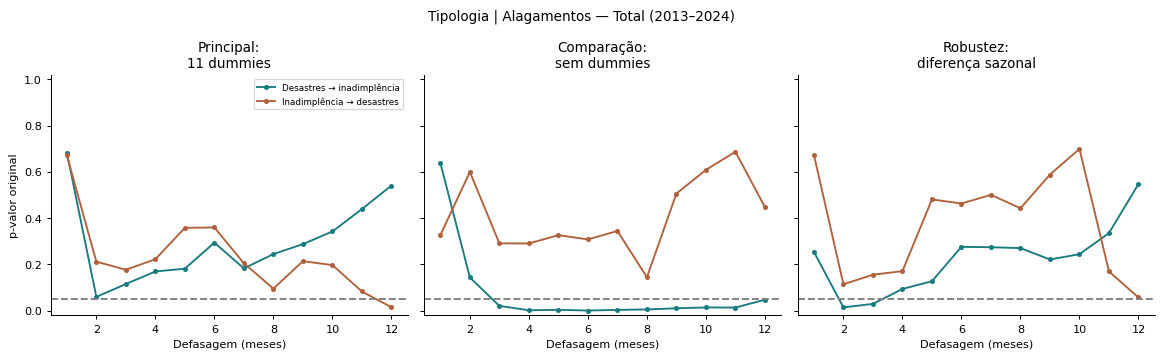

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
60,Principal: 11 dummies,AIC,Desastres → inadimplência,8,1.313832,0.244420,0.783005,1.00000,0.201674,1.648547e-02,135,8,107,8
61,Principal: 11 dummies,AIC,Inadimplência → desastres,8,1.750398,0.095104,0.333573,1.00000,0.103280,7.705048e-03,135,8,107,8
62,Principal: 11 dummies,BIC,Desastres → inadimplência,2,2.883972,0.059641,0.437989,1.00000,0.119799,7.728059e-02,141,2,125,2
63,Principal: 11 dummies,BIC,Inadimplência → desastres,2,1.571862,0.211735,0.460719,1.00000,0.236652,7.703966e-02,141,2,125,2
64,Comparação: sem dummies,AIC,Desastres → inadimplência,8,2.919689,0.005218,0.153274,0.92561,0.001998,1.029265e-06,135,8,118,8
65,Comparação: sem dummies,AIC,Inadimplência → desastres,8,1.559325,0.144414,0.390083,1.00000,0.124594,1.165171e-03,135,8,118,8
66,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.222375,0.637976,0.847699,1.00000,0.664468,6.707302e-01,142,1,139,0
67,Comparação: sem dummies,BIC,Inadimplência → desastres,1,0.968912,0.326662,0.614124,1.00000,0.348956,2.400120e-01,142,1,139,0
68,Robustez: diferença sazonal,AIC,Desastres → inadimplência,12,0.903065,0.546954,0.837887,1.00000,0.330013,1.084768e-06,119,12,94,12
69,Robustez: diferença sazonal,AIC,Inadimplência → desastres,12,1.813159,0.056845,0.229486,1.00000,0.149985,2.742137e-08,119,12,94,12


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
60,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.866466,1.187834e-01,1.383935e-01,-0.098143,False,4.094878e-16,0.078316,Estacionária: convergente,Estacionária: convergente
61,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.866466,1.187834e-01,1.108926e-04,-0.191714,True,9.878934e-01,0.509131,Estacionária: convergente,Estacionária: convergente
62,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.638915,4.982360e-02,3.033986e-01,-0.062167,False,6.983194e-08,0.108655,Estacionária: convergente,Estacionária: convergente
63,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.638915,4.982360e-02,4.909370e-03,-0.139196,False,3.594680e-01,0.424823,Estacionária: convergente,Estacionária: convergente
64,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.953696,9.008618e-02,7.907462e-03,0.104809,False,1.520592e-23,0.260838,Estacionária: convergente,Estacionária: convergente
65,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.953696,9.008618e-02,5.513628e-04,0.003843,False,7.041177e-01,0.346729,Estacionária: convergente,Estacionária: convergente
66,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.170925,1.604558e-13,9.304336e-14,0.396861,True,2.615038e-04,0.171729,Estacionária: convergente,Estacionária: convergente
67,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.170925,1.604558e-13,1.796732e-04,0.167261,True,9.031389e-01,0.697599,Estacionária: convergente,Estacionária: convergente
68,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.973876,1.383369e-05,5.204901e-06,-0.165496,False,4.055333e-02,0.999961,Estacionária: convergente,Conflitante: ambos rejeitam
69,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.973876,1.383369e-05,9.653113e-08,-0.193740,True,6.366750e-01,0.652821,Estacionária: convergente,Conflitante: ambos rejeitam


**Principal: 11 dummies** — AIC: lag 8, p=0.2444, BH=0.783, n=135; BIC: lag 2, p=0.05964, BH=0.438, n=141.

**Comparação: sem dummies** — AIC: lag 8, p=0.005218, BH=0.1533, n=135; BIC: lag 1, p=0.638, BH=0.8477, n=142 (ótimo incluindo zero: 0).

**Robustez: diferença sazonal** — AIC: lag 12, p=0.547, BH=0.8379, n=119; BIC: lag 2, p=0.01392, BH=0.2586, n=129.

Na direção principal, 2/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 0 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 8/12 linhas; 6 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Alagamentos — Pré-pandemia (até jan/2020)

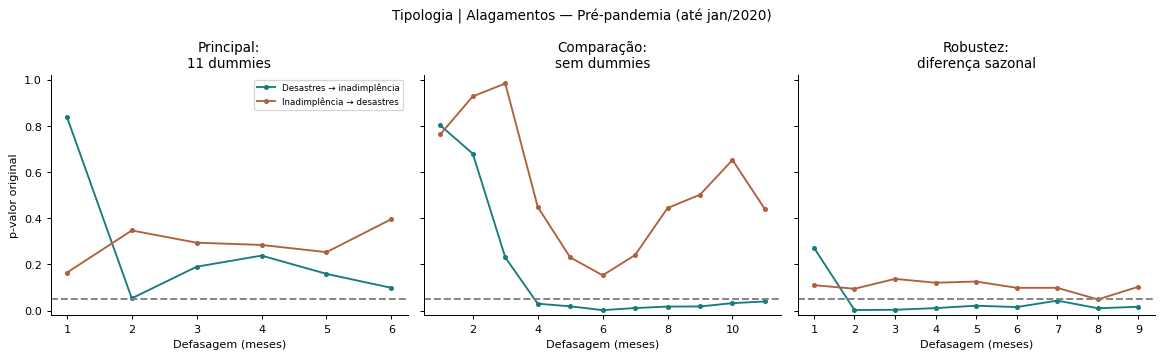

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
312,Principal: 11 dummies,AIC,Desastres → inadimplência,6,1.894067,0.098613,0.570474,1.00000,0.173718,3.687612e-05,78,6,54,6
313,Principal: 11 dummies,AIC,Inadimplência → desastres,6,1.062469,0.396399,0.679775,1.00000,0.270994,2.814463e-02,78,6,54,6
314,Principal: 11 dummies,BIC,Desastres → inadimplência,1,0.041080,0.839981,0.927162,1.00000,0.881069,8.533841e-01,83,1,69,0
315,Principal: 11 dummies,BIC,Inadimplência → desastres,1,1.975426,0.164360,0.415318,1.00000,0.316447,2.188892e-01,83,1,69,0
316,Comparação: sem dummies,AIC,Desastres → inadimplência,6,3.889162,0.002227,0.153274,0.92561,0.000522,6.333326e-09,78,6,65,6
317,Comparação: sem dummies,AIC,Inadimplência → desastres,6,1.630718,0.152868,0.399154,1.00000,0.142419,4.924397e-04,78,6,65,6
318,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.063141,0.802243,0.918632,1.00000,0.842276,8.690671e-01,83,1,80,0
319,Comparação: sem dummies,BIC,Inadimplência → desastres,1,0.090589,0.764210,0.897947,1.00000,0.798769,7.386512e-01,83,1,80,0
320,Robustez: diferença sazonal,AIC,Desastres → inadimplência,6,2.924560,0.015404,0.258566,1.00000,0.007109,6.931176e-05,66,6,53,6
321,Robustez: diferença sazonal,AIC,Inadimplência → desastres,6,1.895158,0.098806,0.341391,1.00000,0.080168,1.981898e-07,66,6,53,6


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
312,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.891003,0.169696,1.286821e-01,-0.121333,False,0.003207,0.715244,Inconclusiva: nenhum rejeita,Estacionária: convergente
313,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.891003,0.169696,1.598475e-01,-0.139342,False,0.527693,0.332602,Inconclusiva: nenhum rejeita,Estacionária: convergente
314,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.269405,0.007212,5.461266e-03,-0.081187,False,0.724842,0.665579,Inconclusiva: nenhum rejeita,Estacionária: convergente
315,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.269405,0.007212,1.891625e-02,-0.173692,False,0.087185,0.130405,Inconclusiva: nenhum rejeita,Estacionária: convergente
316,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.960498,0.608671,9.567331e-02,0.047877,False,0.074063,0.898299,Inconclusiva: nenhum rejeita,Estacionária: convergente
317,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.960498,0.608671,1.384636e-01,0.090348,False,0.742230,0.844567,Inconclusiva: nenhum rejeita,Estacionária: convergente
318,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.119962,0.000003,1.123598e-08,0.369820,True,0.185823,0.173568,Inconclusiva: nenhum rejeita,Estacionária: convergente
319,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.119962,0.000003,2.728636e-02,0.203151,False,0.849896,0.368136,Inconclusiva: nenhum rejeita,Estacionária: convergente
320,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.891691,0.009326,1.722761e-02,-0.309375,True,0.720107,0.860616,Inconclusiva: nenhum rejeita,Estacionária: convergente
321,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.891691,0.009326,3.274977e-03,-0.369737,True,0.777349,0.516508,Inconclusiva: nenhum rejeita,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 6, p=0.09861, BH=0.5705, n=78; BIC: lag 1, p=0.84, BH=0.9272, n=83 (ótimo incluindo zero: 0).

**Comparação: sem dummies** — AIC: lag 6, p=0.002227, BH=0.1533, n=78; BIC: lag 1, p=0.8022, BH=0.9186, n=83 (ótimo incluindo zero: 0).

**Robustez: diferença sazonal** — AIC: lag 6, p=0.0154, BH=0.2586, n=66; BIC: lag 2, p=0.002505, BH=0.1533, n=70.

Na direção principal, 3/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 0 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 8/12 linhas; 4 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Neste recorte, a estacionariedade da inadimplência transformada não tem confirmação conjunta. Os testes Granger são exploratórios; a ausência de rejeição do ADF não demonstra não estacionariedade, mas a limitação impede uma conclusão robusta.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Chuvas Intensas — Total (2013–2024)

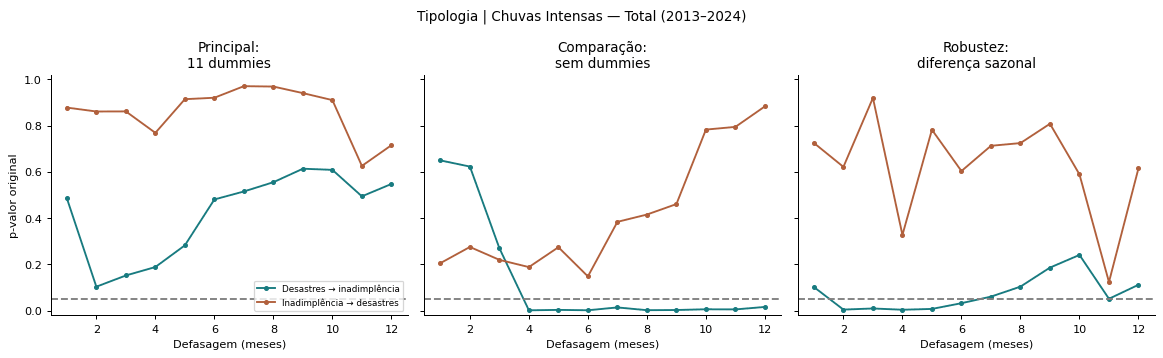

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
72,Principal: 11 dummies,AIC,Desastres → inadimplência,2,2.311252,0.103360,0.570474,1.00000,0.050734,2.191096e-02,141,2,125,2
73,Principal: 11 dummies,AIC,Inadimplência → desastres,2,0.150172,0.860715,0.927333,1.00000,0.826950,6.051085e-01,141,2,125,2
74,Principal: 11 dummies,BIC,Desastres → inadimplência,1,0.489393,0.485468,0.837319,1.00000,0.444087,3.921956e-01,142,1,128,1
75,Principal: 11 dummies,BIC,Inadimplência → desastres,1,0.023791,0.877661,0.933259,1.00000,0.895961,8.836597e-01,142,1,128,1
76,Comparação: sem dummies,AIC,Desastres → inadimplência,11,2.626164,0.005185,0.153274,0.92561,0.005327,3.064531e-14,132,11,109,11
77,Comparação: sem dummies,AIC,Inadimplência → desastres,11,0.636335,0.794198,0.916536,1.00000,0.848105,4.029796e-01,132,11,109,11
78,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.207682,0.649301,0.847699,1.00000,0.588596,5.275325e-01,142,1,139,0
79,Comparação: sem dummies,BIC,Inadimplência → desastres,1,1.619981,0.205219,0.454967,1.00000,0.332660,2.152081e-01,142,1,139,0
80,Robustez: diferença sazonal,AIC,Desastres → inadimplência,12,1.577069,0.111667,0.570474,1.00000,0.242554,8.142311e-04,119,12,94,12
81,Robustez: diferença sazonal,AIC,Inadimplência → desastres,12,0.834410,0.615033,0.816569,1.00000,0.600489,3.889186e-04,119,12,94,12


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
72,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.656879,4.653994e-01,3.118475e-01,-0.025072,False,2.472877e-06,0.128941,Estacionária: convergente,Estacionária: convergente
73,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.656879,4.653994e-01,9.251826e-02,-0.080383,False,1.680158e-01,0.077381,Estacionária: convergente,Estacionária: convergente
74,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.458894,1.057227e-01,1.865226e-01,-0.030859,False,3.975818e-07,0.454425,Estacionária: convergente,Estacionária: convergente
75,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.458894,1.057227e-01,7.874482e-03,-0.074569,False,3.369606e-01,0.027048,Estacionária: convergente,Estacionária: convergente
76,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.971914,1.641633e-02,2.080097e-04,0.132946,False,1.625522e-17,0.304585,Estacionária: convergente,Estacionária: convergente
77,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.971914,1.641633e-02,1.622874e-05,-0.113289,False,9.316244e-01,0.421577,Estacionária: convergente,Estacionária: convergente
78,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.203935,2.769433e-13,7.452911e-15,0.409448,True,1.992898e-04,0.266394,Estacionária: convergente,Estacionária: convergente
79,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.203935,2.769433e-13,9.364482e-04,0.223231,True,5.254119e-01,0.063795,Estacionária: convergente,Estacionária: convergente
80,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.970826,3.045424e-03,4.450718e-07,-0.094300,False,3.816867e-01,0.996354,Estacionária: convergente,Estacionária: convergente
81,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.970826,3.045424e-03,1.765855e-08,-0.100033,False,1.948214e-01,0.345071,Estacionária: convergente,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 2, p=0.1034, BH=0.5705, n=141; BIC: lag 1, p=0.4855, BH=0.8373, n=142.

**Comparação: sem dummies** — AIC: lag 11, p=0.005185, BH=0.1533, n=132; BIC: lag 1, p=0.6493, BH=0.8477, n=142 (ótimo incluindo zero: 0).

**Robustez: diferença sazonal** — AIC: lag 12, p=0.1117, BH=0.5705, n=119; BIC: lag 1, p=0.102, BH=0.5705, n=130.

Na direção principal, 1/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 0 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 8/12 linhas; 4 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Chuvas Intensas — Pré-pandemia (até jan/2020)

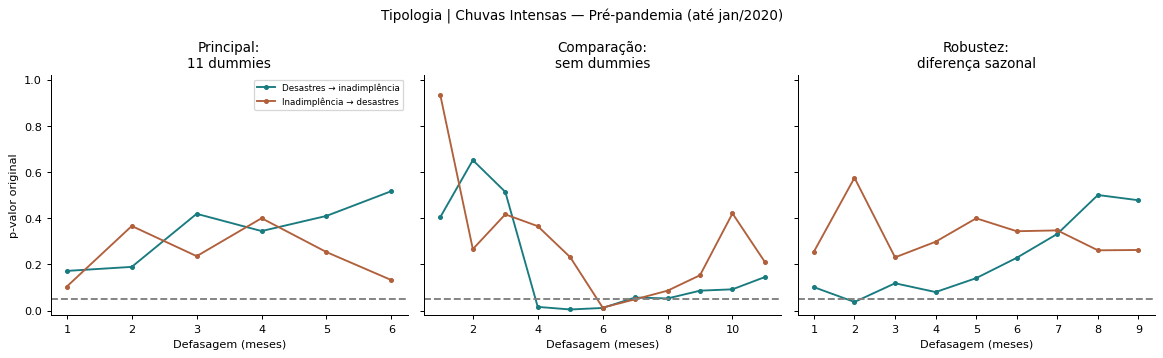

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
324,Principal: 11 dummies,AIC,Desastres → inadimplência,3,0.955391,0.419417,0.830090,1.000000,0.466802,7.353106e-03,81,3,63,3
325,Principal: 11 dummies,AIC,Inadimplência → desastres,3,1.453215,0.235854,0.494872,1.000000,0.307304,5.267407e-02,81,3,63,3
326,Principal: 11 dummies,BIC,Desastres → inadimplência,1,1.904144,0.172070,0.673942,1.000000,0.194275,7.441576e-03,83,1,69,1
327,Principal: 11 dummies,BIC,Inadimplência → desastres,1,2.707451,0.104429,0.345644,1.000000,0.163329,1.187150e-01,83,1,69,1
328,Comparação: sem dummies,AIC,Desastres → inadimplência,6,3.019120,0.011505,0.258566,1.000000,0.010508,1.036114e-10,78,6,65,6
329,Comparação: sem dummies,AIC,Inadimplência → desastres,6,2.946883,0.013195,0.123114,0.743475,0.015510,4.437854e-04,78,6,65,6
330,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.698644,0.405729,0.830090,1.000000,0.368527,2.237677e-01,83,1,80,0
331,Comparação: sem dummies,BIC,Inadimplência → desastres,1,0.007292,0.932164,0.966146,1.000000,0.955975,9.400854e-01,83,1,80,0
332,Robustez: diferença sazonal,AIC,Desastres → inadimplência,3,2.032201,0.118553,0.571768,1.000000,0.181639,1.719590e-04,69,3,62,3
333,Robustez: diferença sazonal,AIC,Inadimplência → desastres,3,1.472393,0.230751,0.488527,1.000000,0.317563,4.724288e-01,69,3,62,3


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
324,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.851720,5.453876e-01,2.321292e-01,-0.132540,False,0.169262,0.179584,Inconclusiva: nenhum rejeita,Estacionária: convergente
325,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.851720,5.453876e-01,4.824681e-01,-0.017643,False,0.222712,0.227196,Inconclusiva: nenhum rejeita,Estacionária: convergente
326,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.291917,2.618700e-01,5.999967e-03,-0.056315,False,0.889725,0.944715,Inconclusiva: nenhum rejeita,Estacionária: convergente
327,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.291917,2.618700e-01,5.051109e-01,0.013087,False,0.132102,0.048014,Inconclusiva: nenhum rejeita,Estacionária: convergente
328,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.952032,5.924810e-01,2.303441e-02,0.024274,False,0.012038,0.966917,Inconclusiva: nenhum rejeita,Estacionária: convergente
329,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.952032,5.924810e-01,3.179478e-02,0.121798,False,0.966634,0.307934,Inconclusiva: nenhum rejeita,Estacionária: convergente
330,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.233848,5.604100e-07,1.106589e-09,0.378141,True,0.188975,0.610653,Inconclusiva: nenhum rejeita,Estacionária: convergente
331,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.233848,5.604100e-07,4.468408e-02,0.287529,True,0.693463,0.071825,Inconclusiva: nenhum rejeita,Estacionária: convergente
332,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.783587,8.292452e-02,3.485440e-02,-0.342052,True,0.936701,0.464642,Inconclusiva: nenhum rejeita,Estacionária: convergente
333,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.783587,8.292452e-02,2.560965e-03,-0.379511,True,0.244571,0.956747,Inconclusiva: nenhum rejeita,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 3, p=0.4194, BH=0.8301, n=81; BIC: lag 1, p=0.1721, BH=0.6739, n=83.

**Comparação: sem dummies** — AIC: lag 6, p=0.01151, BH=0.2586, n=78; BIC: lag 1, p=0.4057, BH=0.8301, n=83 (ótimo incluindo zero: 0).

**Robustez: diferença sazonal** — AIC: lag 3, p=0.1186, BH=0.5718, n=69; BIC: lag 1, p=0.1017, BH=0.5705, n=71 (ótimo incluindo zero: 0).

Na direção principal, 1/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 1 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 4/12 linhas; 6 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Neste recorte, a estacionariedade da inadimplência transformada não tem confirmação conjunta. Os testes Granger são exploratórios; a ausência de rejeição do ADF não demonstra não estacionariedade, mas a limitação impede uma conclusão robusta.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Doenças infecciosas — Total (2013–2024)

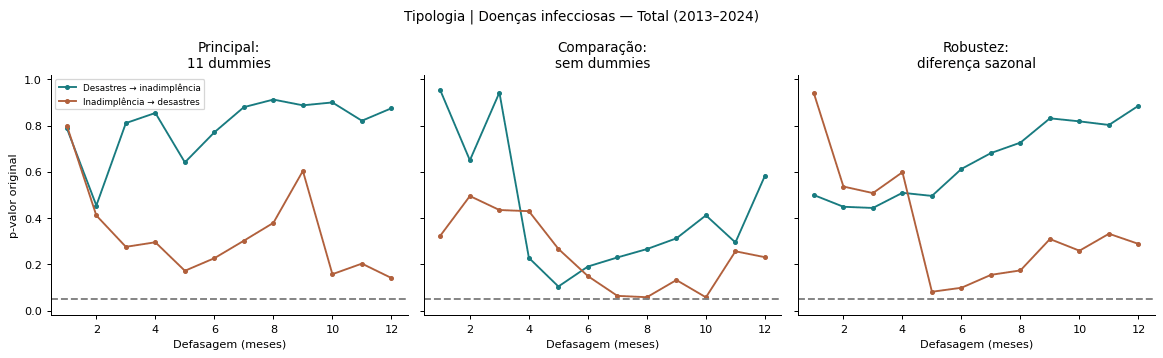

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
84,Principal: 11 dummies,AIC,Desastres → inadimplência,11,0.604748,0.820743,0.927162,1.0,0.789880,2.569159e-02,132,11,98,11
85,Principal: 11 dummies,AIC,Inadimplência → desastres,11,1.361866,0.203237,0.454863,1.0,0.551928,8.525942e-02,132,11,98,11
86,Principal: 11 dummies,BIC,Desastres → inadimplência,1,0.072476,0.788199,0.912447,1.0,0.812226,7.708695e-01,142,1,128,1
87,Principal: 11 dummies,BIC,Inadimplência → desastres,1,0.064761,0.799532,0.916536,1.0,0.825480,7.759155e-01,142,1,128,1
88,Comparação: sem dummies,AIC,Desastres → inadimplência,11,1.201679,0.294527,0.830090,1.0,0.310260,1.330482e-08,132,11,109,11
89,Comparação: sem dummies,AIC,Inadimplência → desastres,11,1.261544,0.256466,0.519565,1.0,0.606748,1.636078e-01,132,11,109,11
90,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.003712,0.951503,0.980763,1.0,0.950176,9.432614e-01,142,1,139,1
91,Comparação: sem dummies,BIC,Inadimplência → desastres,1,0.978398,0.324313,0.614124,1.0,0.392473,3.931363e-01,142,1,139,1
92,Robustez: diferença sazonal,AIC,Desastres → inadimplência,5,0.881647,0.495851,0.837319,1.0,0.354560,5.373113e-02,126,5,115,5
93,Robustez: diferença sazonal,AIC,Inadimplência → desastres,5,2.015949,0.081508,0.308943,1.0,0.025710,6.365574e-08,126,5,115,5


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
84,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.927681,3.822338e-02,2.583440e-02,-0.074089,False,7.062664e-21,0.281991,Estacionária: convergente,Estacionária: convergente
85,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.927681,3.822338e-02,9.656329e-04,-0.007822,False,4.839477e-42,0.022557,Estacionária: convergente,Estacionária: convergente
86,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.460522,1.809748e-02,1.608660e-01,-0.040935,False,3.354588e-06,0.459720,Estacionária: convergente,Estacionária: convergente
87,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.460522,1.809748e-02,9.138575e-04,0.260033,True,7.906799e-35,0.001223,Estacionária: convergente,Estacionária: convergente
88,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.963822,1.821078e-02,1.409345e-03,0.127518,False,1.020168e-20,0.498097,Estacionária: convergente,Estacionária: convergente
89,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.963822,1.821078e-02,1.968473e-03,0.054993,False,8.642203e-108,0.396479,Estacionária: convergente,Estacionária: convergente
90,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.339828,7.162265e-13,3.593928e-14,0.403948,True,2.764708e-04,0.095142,Estacionária: convergente,Estacionária: convergente
91,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.339828,7.162265e-13,4.644164e-06,0.376359,True,8.160438e-123,0.497922,Estacionária: convergente,Estacionária: convergente
92,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.782112,1.812240e-03,7.861831e-06,-0.414736,True,8.511956e-06,0.970974,Estacionária: convergente,Estacionária: convergente
93,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.782112,1.812240e-03,1.559480e-02,-0.145472,False,3.063958e-24,0.709878,Estacionária: convergente,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 11, p=0.8207, BH=0.9272, n=132; BIC: lag 1, p=0.7882, BH=0.9124, n=142.

**Comparação: sem dummies** — AIC: lag 11, p=0.2945, BH=0.8301, n=132; BIC: lag 1, p=0.9515, BH=0.9808, n=142.

**Robustez: diferença sazonal** — AIC: lag 5, p=0.4959, BH=0.8373, n=126; BIC: lag 1, p=0.4995, BH=0.8373, n=130.

Na direção principal, 0/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 0 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 12/12 linhas; 5 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Doenças infecciosas — Pré-pandemia (até jan/2020)

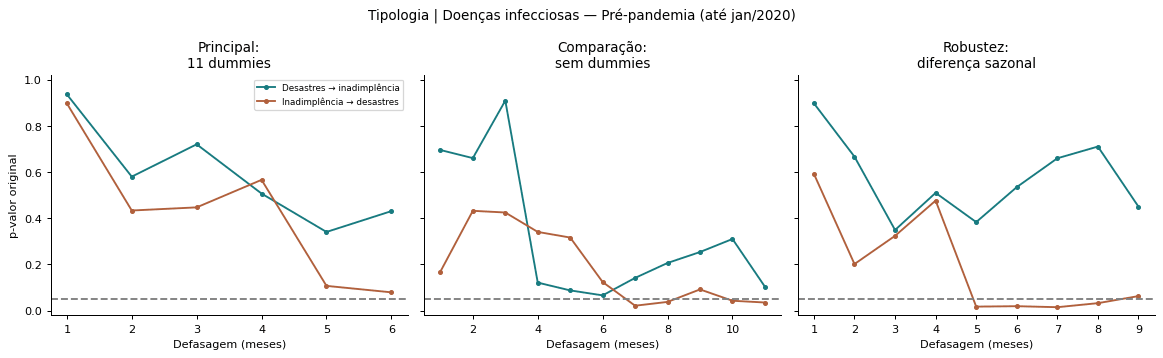

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
336,Principal: 11 dummies,AIC,Desastres → inadimplência,6,1.006228,0.431002,0.830090,1.000000,0.639832,2.595327e-02,78,6,54,6
337,Principal: 11 dummies,AIC,Inadimplência → desastres,6,2.016589,0.079246,0.305293,1.000000,0.040379,3.150337e-08,78,6,54,6
338,Principal: 11 dummies,BIC,Desastres → inadimplência,3,0.446827,0.720399,0.883025,1.000000,0.675872,2.001772e-01,81,3,63,0
339,Principal: 11 dummies,BIC,Inadimplência → desastres,3,0.897990,0.447294,0.724924,1.000000,0.633497,1.514487e-01,81,3,63,0
340,Comparação: sem dummies,AIC,Desastres → inadimplência,11,1.688423,0.103537,0.570474,1.000000,0.295277,2.502402e-07,73,11,50,11
341,Comparação: sem dummies,AIC,Inadimplência → desastres,11,2.126502,0.035211,0.197013,1.000000,0.329339,2.210989e-02,73,11,50,11
342,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.154052,0.695736,0.883025,1.000000,0.682527,5.892209e-01,83,1,80,0
343,Comparação: sem dummies,BIC,Inadimplência → desastres,1,1.926706,0.168973,0.420900,1.000000,0.287825,2.514177e-01,83,1,80,0
344,Robustez: diferença sazonal,AIC,Desastres → inadimplência,5,1.076215,0.383460,0.830090,1.000000,0.359208,3.520763e-02,67,5,56,5
345,Robustez: diferença sazonal,AIC,Inadimplência → desastres,5,3.024668,0.017381,0.127638,0.770798,0.007303,6.595670e-08,67,5,56,5


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
336,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.849313,3.365508e-03,3.108116e-02,-0.213002,False,1.043132e-01,0.601665,Inconclusiva: nenhum rejeita,Estacionária: convergente
337,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.849313,3.365508e-03,8.193051e-04,0.233349,True,3.788021e-17,0.007893,Inconclusiva: nenhum rejeita,Estacionária: convergente
338,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.848522,4.257202e-02,1.392297e-01,-0.130553,False,1.677508e-02,0.623128,Inconclusiva: nenhum rejeita,Estacionária: convergente
339,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.848522,4.257202e-02,9.628333e-02,0.183108,False,1.126535e-03,0.002635,Inconclusiva: nenhum rejeita,Estacionária: convergente
340,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.977815,4.882938e-03,1.832890e-02,-0.139338,False,7.672408e-01,0.616342,Inconclusiva: nenhum rejeita,Estacionária: convergente
341,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.977815,4.882938e-03,7.054283e-03,0.108928,False,1.187037e-05,0.218472,Inconclusiva: nenhum rejeita,Estacionária: convergente
342,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.274167,5.190107e-07,2.446415e-08,0.363775,True,1.399994e-01,0.807197,Inconclusiva: nenhum rejeita,Estacionária: convergente
343,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.274167,5.190107e-07,1.133861e-03,0.404144,True,3.278116e-22,0.477544,Inconclusiva: nenhum rejeita,Estacionária: convergente
344,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.859359,1.693508e-02,1.076430e-03,-0.405425,True,7.225487e-01,0.751589,Inconclusiva: nenhum rejeita,Estacionária: convergente
345,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.859359,1.693508e-02,4.616623e-02,0.081261,False,3.494961e-04,0.672000,Inconclusiva: nenhum rejeita,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 6, p=0.431, BH=0.8301, n=78; BIC: lag 3, p=0.7204, BH=0.883, n=81 (ótimo incluindo zero: 0).

**Comparação: sem dummies** — AIC: lag 11, p=0.1035, BH=0.5705, n=73; BIC: lag 1, p=0.6957, BH=0.883, n=83 (ótimo incluindo zero: 0).

**Robustez: diferença sazonal** — AIC: lag 5, p=0.3835, BH=0.8301, n=67; BIC: lag 1, p=0.898, BH=0.9548, n=71 (ótimo incluindo zero: 0).

Na direção principal, 0/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 2 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 12/12 linhas; 5 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Neste recorte, a estacionariedade da inadimplência transformada não tem confirmação conjunta. Os testes Granger são exploratórios; a ausência de rejeição do ADF não demonstra não estacionariedade, mas a limitação impede uma conclusão robusta.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Enxurradas — Total (2013–2024)

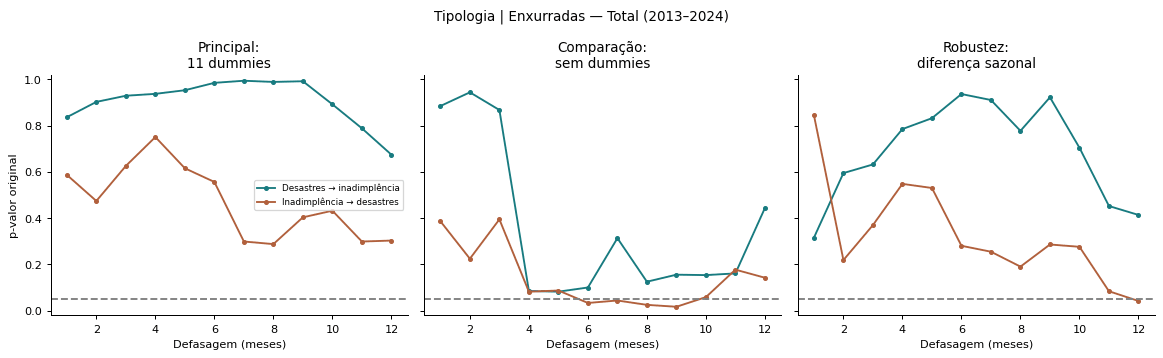

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
96,Principal: 11 dummies,AIC,Desastres → inadimplência,4,0.201665,0.937013,0.979090,1.000000,0.943733,7.921613e-01,139,4,119,4
97,Principal: 11 dummies,AIC,Inadimplência → desastres,4,0.480078,0.750304,0.896667,1.000000,0.675726,3.539497e-02,139,4,119,4
98,Principal: 11 dummies,BIC,Desastres → inadimplência,1,0.043047,0.835967,0.927162,1.000000,0.827382,7.971987e-01,142,1,128,1
99,Principal: 11 dummies,BIC,Inadimplência → desastres,1,0.296905,0.586778,0.806519,1.000000,0.649891,5.015941e-01,142,1,128,1
100,Comparação: sem dummies,AIC,Desastres → inadimplência,9,1.502046,0.155347,0.655870,1.000000,0.171208,1.657772e-03,134,9,115,9
101,Comparação: sem dummies,AIC,Inadimplência → desastres,9,2.377622,0.016666,0.127638,0.770798,0.012091,2.766393e-10,134,9,115,9
102,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.021243,0.884329,0.949633,1.000000,0.878250,8.823098e-01,142,1,139,0
103,Comparação: sem dummies,BIC,Inadimplência → desastres,1,0.754786,0.386463,0.677752,1.000000,0.475084,3.970214e-01,142,1,139,0
104,Robustez: diferença sazonal,AIC,Desastres → inadimplência,12,1.047067,0.413614,0.830090,1.000000,0.697862,6.875122e-02,119,12,94,12
105,Robustez: diferença sazonal,AIC,Inadimplência → desastres,12,1.916711,0.041800,0.209000,1.000000,0.016436,6.781224e-06,119,12,94,12


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
96,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.719887,3.663887e-02,2.730915e-01,-0.067824,False,8.270316e-24,0.027800,Estacionária: convergente,Estacionária: convergente
97,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.719887,3.663887e-02,5.787356e-04,-0.224437,True,1.683859e-01,0.002805,Estacionária: convergente,Estacionária: convergente
98,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.460390,2.240003e-02,1.541634e-01,-0.039657,False,1.418400e-06,0.492485,Estacionária: convergente,Estacionária: convergente
99,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.460390,2.240003e-02,1.895220e-03,-0.211954,True,6.313496e-03,0.016611,Estacionária: convergente,Estacionária: convergente
100,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.951536,4.609442e-02,1.366849e-02,0.115597,False,5.069612e-21,0.326806,Estacionária: convergente,Estacionária: convergente
101,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.951536,4.609442e-02,1.593117e-03,-0.066447,False,2.450832e-01,0.235581,Estacionária: convergente,Estacionária: convergente
102,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.290949,1.520116e-11,6.424650e-14,0.401850,True,3.104437e-04,0.223914,Estacionária: convergente,Estacionária: convergente
103,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.290949,1.520116e-11,8.312196e-02,0.095665,False,8.016587e-02,0.010537,Estacionária: convergente,Estacionária: convergente
104,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.981237,5.685219e-04,8.772716e-06,-0.146555,False,7.338256e-01,0.939828,Estacionária: convergente,Estacionária: convergente
105,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.981237,5.685219e-04,2.759033e-06,-0.175835,False,3.526460e-01,0.497212,Estacionária: convergente,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 4, p=0.937, BH=0.9791, n=139; BIC: lag 1, p=0.836, BH=0.9272, n=142.

**Comparação: sem dummies** — AIC: lag 9, p=0.1553, BH=0.6559, n=134; BIC: lag 1, p=0.8843, BH=0.9496, n=142 (ótimo incluindo zero: 0).

**Robustez: diferença sazonal** — AIC: lag 12, p=0.4136, BH=0.8301, n=119; BIC: lag 1, p=0.3153, BH=0.8301, n=130.

Na direção principal, 0/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 2 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 12/12 linhas; 5 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Enxurradas — Pré-pandemia (até jan/2020)

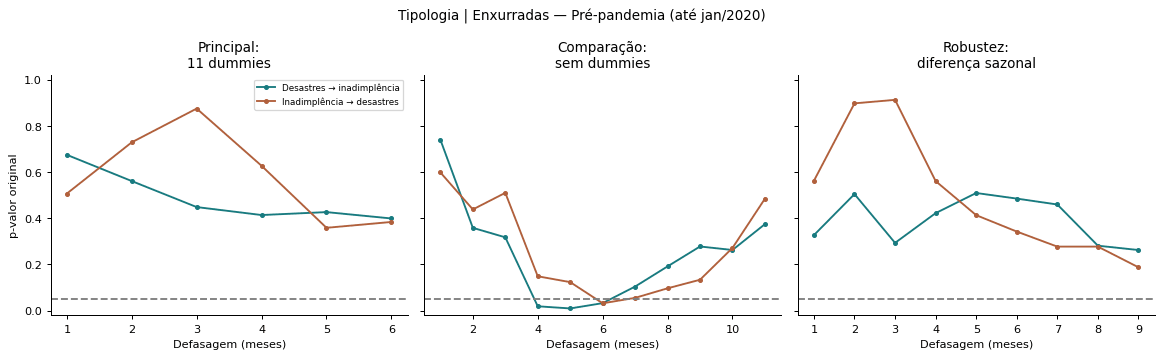

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
348,Principal: 11 dummies,AIC,Desastres → inadimplência,4,1.001238,0.414092,0.830090,1.0,0.220561,8.406441e-04,80,4,60,4
349,Principal: 11 dummies,AIC,Inadimplência → desastres,4,0.652639,0.627275,0.823518,1.0,0.729586,1.636221e-01,80,4,60,4
350,Principal: 11 dummies,BIC,Desastres → inadimplência,1,0.177488,0.674850,0.871373,1.0,0.708622,6.155347e-01,83,1,69,0
351,Principal: 11 dummies,BIC,Inadimplência → desastres,1,0.444858,0.507011,0.768695,1.0,0.633860,5.612395e-01,83,1,69,0
352,Comparação: sem dummies,AIC,Desastres → inadimplência,6,2.472456,0.032409,0.331134,1.0,0.025301,1.209715e-06,78,6,65,6
353,Comparação: sem dummies,AIC,Inadimplência → desastres,6,2.482036,0.031828,0.182431,1.0,0.016190,5.406032e-11,78,6,65,6
354,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.110683,0.740238,0.883025,1.0,0.737295,7.526217e-01,83,1,80,0
355,Comparação: sem dummies,BIC,Inadimplência → desastres,1,0.279307,0.598619,0.806519,1.0,0.739969,7.151849e-01,83,1,80,0
356,Robustez: diferença sazonal,AIC,Desastres → inadimplência,5,0.866363,0.509518,0.837319,1.0,0.203488,6.023798e-04,67,5,56,5
357,Robustez: diferença sazonal,AIC,Inadimplência → desastres,5,1.022202,0.413470,0.679775,1.0,0.236119,2.854422e-03,67,5,56,5


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
348,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.831705,2.859018e-01,2.973459e-02,-0.169098,False,0.001284,0.326094,Inconclusiva: nenhum rejeita,Estacionária: convergente
349,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.831705,2.859018e-01,9.203842e-03,-0.167391,False,0.514976,0.003144,Inconclusiva: nenhum rejeita,Estacionária: convergente
350,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.263419,7.966377e-02,4.660153e-03,-0.067347,False,0.791379,0.973073,Inconclusiva: nenhum rejeita,Estacionária: convergente
351,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.263419,7.966377e-02,7.230401e-02,-0.143188,False,0.004725,0.041671,Inconclusiva: nenhum rejeita,Estacionária: convergente
352,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.953214,9.030847e-01,7.140605e-02,0.018340,False,0.015270,0.914114,Inconclusiva: nenhum rejeita,Estacionária: convergente
353,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.953214,9.030847e-01,7.393530e-03,0.123832,False,0.059631,0.612114,Inconclusiva: nenhum rejeita,Estacionária: convergente
354,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.266460,3.753645e-07,5.391948e-09,0.370810,True,0.157512,0.796933,Inconclusiva: nenhum rejeita,Estacionária: convergente
355,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.266460,3.753645e-07,8.393801e-02,0.230040,True,0.046143,0.034567,Inconclusiva: nenhum rejeita,Estacionária: convergente
356,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.812833,4.293948e-03,2.948515e-04,-0.367774,True,0.654466,0.783513,Inconclusiva: nenhum rejeita,Estacionária: convergente
357,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.812833,4.293948e-03,9.582264e-06,-0.456682,True,0.844126,0.656394,Inconclusiva: nenhum rejeita,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 4, p=0.4141, BH=0.8301, n=80; BIC: lag 1, p=0.6749, BH=0.8714, n=83 (ótimo incluindo zero: 0).

**Comparação: sem dummies** — AIC: lag 6, p=0.03241, BH=0.3311, n=78; BIC: lag 1, p=0.7402, BH=0.883, n=83 (ótimo incluindo zero: 0).

**Robustez: diferença sazonal** — AIC: lag 5, p=0.5095, BH=0.8373, n=67; BIC: lag 1, p=0.327, BH=0.8301, n=71 (ótimo incluindo zero: 0).

Na direção principal, 1/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 1 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 6/12 linhas; 6 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Neste recorte, a estacionariedade da inadimplência transformada não tem confirmação conjunta. Os testes Granger são exploratórios; a ausência de rejeição do ADF não demonstra não estacionariedade, mas a limitação impede uma conclusão robusta.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Erosão — Total (2013–2024)

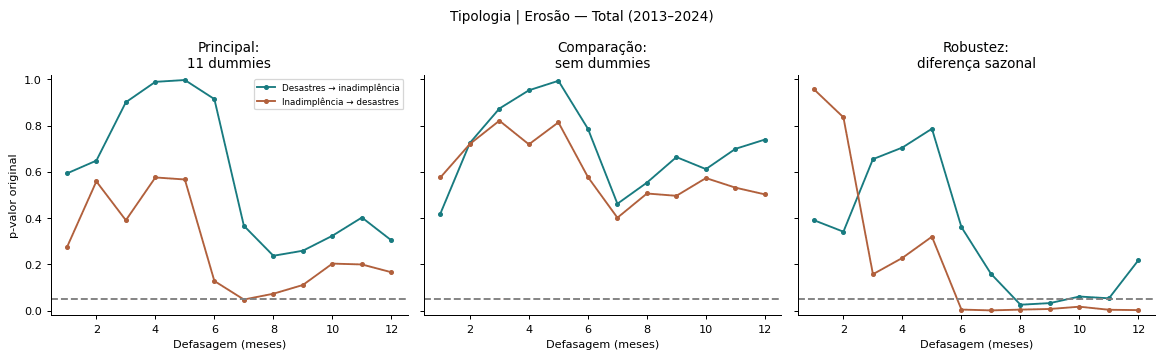

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
108,Principal: 11 dummies,AIC,Desastres → inadimplência,7,1.102471,0.366721,0.830090,1.000000,0.242837,2.925316e-03,136,7,110,7
109,Principal: 11 dummies,AIC,Inadimplência → desastres,7,2.113394,0.047902,0.220726,1.000000,0.061324,8.051863e-07,136,7,110,7
110,Principal: 11 dummies,BIC,Desastres → inadimplência,2,0.434784,0.648380,0.847699,1.000000,0.602027,6.744849e-01,141,2,125,2
111,Principal: 11 dummies,BIC,Inadimplência → desastres,2,0.585134,0.558549,0.796142,1.000000,0.538191,3.484044e-01,141,2,125,2
112,Comparação: sem dummies,AIC,Desastres → inadimplência,7,0.962233,0.461981,0.837319,1.000000,0.279275,9.524498e-03,136,7,121,7
113,Comparação: sem dummies,AIC,Inadimplência → desastres,7,1.048042,0.401516,0.679775,1.000000,0.282390,9.344986e-02,136,7,121,7
114,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.655851,0.419413,0.830090,1.000000,0.385395,3.562115e-01,142,1,139,1
115,Comparação: sem dummies,BIC,Inadimplência → desastres,1,0.315054,0.575499,0.800250,1.000000,0.544556,3.754069e-01,142,1,139,1
116,Robustez: diferença sazonal,AIC,Desastres → inadimplência,12,1.323703,0.218355,0.754610,1.000000,0.106927,2.658567e-06,119,12,94,12
117,Robustez: diferença sazonal,AIC,Inadimplência → desastres,12,2.858407,0.002159,0.050737,0.306397,0.000452,6.542114e-23,119,12,94,12


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
108,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.843887,1.351621e-01,8.304955e-02,-0.063670,False,9.820656e-22,0.221758,Estacionária: convergente,Estacionária: convergente
109,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.843887,1.351621e-01,7.154086e-04,-0.110995,False,5.170835e-02,0.141137,Estacionária: convergente,Estacionária: convergente
110,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.667152,7.793148e-03,2.534920e-01,-0.047470,False,4.547535e-09,0.118936,Estacionária: convergente,Estacionária: convergente
111,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.667152,7.793148e-03,3.237136e-03,-0.088260,False,3.103699e-01,0.159715,Estacionária: convergente,Estacionária: convergente
112,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.940191,2.669851e-02,3.753463e-04,0.238348,True,1.598587e-21,0.400894,Estacionária: convergente,Estacionária: convergente
113,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.940191,2.669851e-02,1.429848e-03,-0.024143,False,1.675914e-01,0.619371,Estacionária: convergente,Estacionária: convergente
114,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.465928,3.916246e-13,3.178209e-14,0.401087,True,1.294758e-04,0.204576,Estacionária: convergente,Estacionária: convergente
115,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.465928,3.916246e-13,9.951881e-07,-0.076081,False,4.645791e-01,0.467405,Estacionária: convergente,Estacionária: convergente
116,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.974417,3.262985e-04,1.794567e-05,-0.238066,True,4.091652e-01,0.884581,Estacionária: convergente,Estacionária: convergente
117,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.974417,3.262985e-04,6.805330e-05,-0.100721,False,3.481055e-01,0.720592,Estacionária: convergente,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 7, p=0.3667, BH=0.8301, n=136; BIC: lag 2, p=0.6484, BH=0.8477, n=141.

**Comparação: sem dummies** — AIC: lag 7, p=0.462, BH=0.8373, n=136; BIC: lag 1, p=0.4194, BH=0.8301, n=142.

**Robustez: diferença sazonal** — AIC: lag 12, p=0.2184, BH=0.7546, n=119; BIC: lag 2, p=0.3411, BH=0.8301, n=129.

Na direção principal, 0/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 2 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 10/12 linhas; 5 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Erosão — Pré-pandemia (até jan/2020)

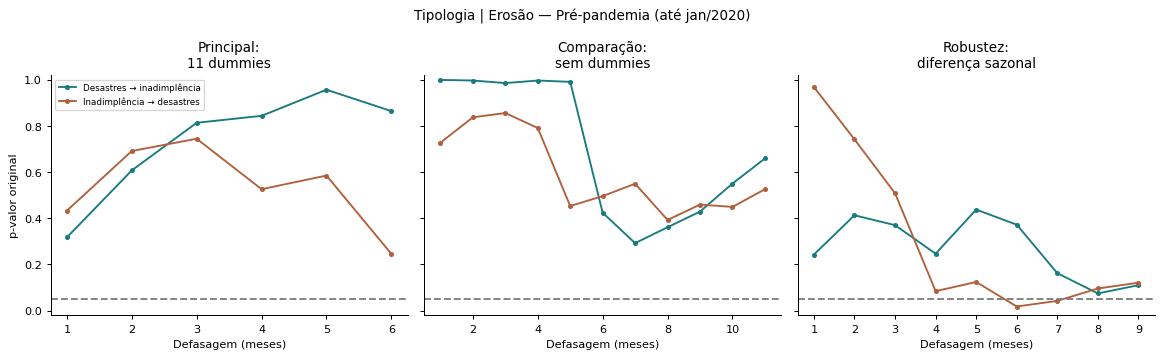

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
360,Principal: 11 dummies,AIC,Desastres → inadimplência,3,0.316103,0.813673,0.923735,1.0,0.896623,0.559239,81,3,63,3
361,Principal: 11 dummies,AIC,Inadimplência → desastres,3,0.412596,0.744519,0.896667,1.0,0.786858,0.504509,81,3,63,3
362,Principal: 11 dummies,BIC,Desastres → inadimplência,3,0.316103,0.813673,0.923735,1.0,0.896623,0.559239,81,3,63,3
363,Principal: 11 dummies,BIC,Inadimplência → desastres,3,0.412596,0.744519,0.896667,1.0,0.786858,0.504509,81,3,63,3
364,Comparação: sem dummies,AIC,Desastres → inadimplência,6,1.013938,0.424159,0.830090,1.0,0.422158,0.000452,78,6,65,6
365,Comparação: sem dummies,AIC,Inadimplência → desastres,6,0.906324,0.496025,0.766880,1.0,0.149619,0.022772,78,6,65,6
366,Comparação: sem dummies,BIC,Desastres → inadimplência,2,0.003195,0.996810,0.996810,1.0,0.997620,0.995005,82,2,77,2
367,Comparação: sem dummies,BIC,Inadimplência → desastres,2,0.178028,0.837263,0.927333,1.0,0.775086,0.403713,82,2,77,2
368,Robustez: diferença sazonal,AIC,Desastres → inadimplência,4,1.395698,0.246563,0.783005,1.0,0.379333,0.001031,68,4,59,4
369,Robustez: diferença sazonal,AIC,Inadimplência → desastres,4,2.162280,0.084347,0.310811,1.0,0.063211,0.005971,68,4,59,4


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
360,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.850145,0.055490,1.360478e-01,-0.132477,False,0.034469,0.560555,Inconclusiva: nenhum rejeita,Estacionária: convergente
361,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.850145,0.055490,1.217425e-02,-0.223500,True,0.317412,0.342367,Inconclusiva: nenhum rejeita,Estacionária: convergente
362,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.850145,0.055490,1.360478e-01,-0.132477,False,0.034469,0.560555,Inconclusiva: nenhum rejeita,Estacionária: convergente
363,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.850145,0.055490,1.217425e-02,-0.223500,True,0.317412,0.342367,Inconclusiva: nenhum rejeita,Estacionária: convergente
364,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.950662,0.246655,3.050391e-02,0.104595,False,0.468584,0.753211,Inconclusiva: nenhum rejeita,Estacionária: convergente
365,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.950662,0.246655,6.218674e-03,-0.134312,False,0.243923,0.467407,Inconclusiva: nenhum rejeita,Estacionária: convergente
366,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.695440,0.000004,3.284784e-10,0.387148,True,0.142553,0.571777,Inconclusiva: nenhum rejeita,Estacionária: convergente
367,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.695440,0.000004,4.111873e-03,-0.078226,False,0.695329,0.399006,Inconclusiva: nenhum rejeita,Estacionária: convergente
368,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.834203,0.007782,1.102872e-03,-0.394764,True,0.796525,0.951273,Inconclusiva: nenhum rejeita,Inconclusiva: nenhum rejeita
369,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.834203,0.007782,5.418067e-03,-0.389267,True,0.670215,0.317657,Inconclusiva: nenhum rejeita,Inconclusiva: nenhum rejeita


**Principal: 11 dummies** — AIC: lag 3, p=0.8137, BH=0.9237, n=81; BIC: lag 3, p=0.8137, BH=0.9237, n=81.

**Comparação: sem dummies** — AIC: lag 6, p=0.4242, BH=0.8301, n=78; BIC: lag 2, p=0.9968, BH=0.9968, n=82.

**Robustez: diferença sazonal** — AIC: lag 4, p=0.2466, BH=0.783, n=68; BIC: lag 2, p=0.413, BH=0.8301, n=70.

Na direção principal, 0/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 0 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 6/12 linhas; 7 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Neste recorte, a estacionariedade da inadimplência transformada não tem confirmação conjunta. Os testes Granger são exploratórios; a ausência de rejeição do ADF não demonstra não estacionariedade, mas a limitação impede uma conclusão robusta.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Estiagem e Seca — Total (2013–2024)

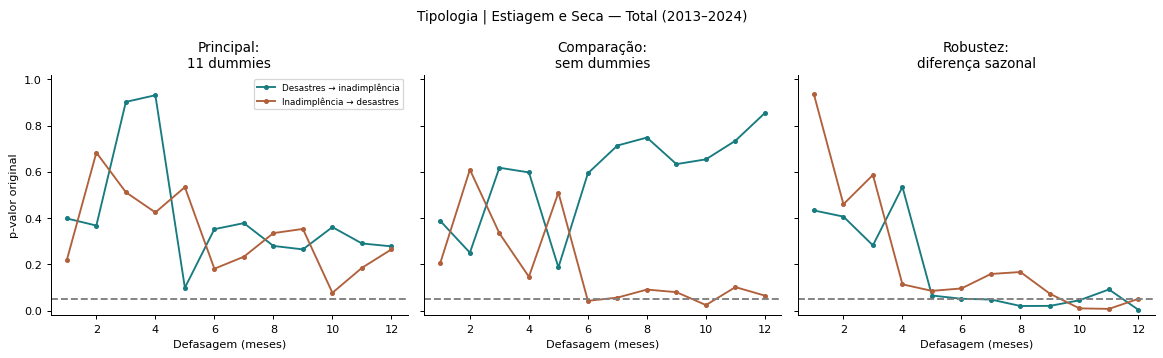

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
120,Principal: 11 dummies,AIC,Desastres → inadimplência,5,1.904789,0.098763,0.570474,1.00000,0.274840,1.922716e-01,138,5,116,5
121,Principal: 11 dummies,AIC,Inadimplência → desastres,5,0.825870,0.533746,0.789858,1.00000,0.776449,2.541838e-01,138,5,116,5
122,Principal: 11 dummies,BIC,Desastres → inadimplência,1,0.717900,0.398415,0.830090,1.00000,0.461172,5.363309e-01,142,1,128,1
123,Principal: 11 dummies,BIC,Inadimplência → desastres,1,1.526378,0.218920,0.471983,1.00000,0.310632,1.194862e-01,142,1,128,1
124,Comparação: sem dummies,AIC,Desastres → inadimplência,7,0.650119,0.713626,0.883025,1.00000,0.734806,1.357919e-01,136,7,121,7
125,Comparação: sem dummies,AIC,Inadimplência → desastres,7,2.032929,0.056241,0.229486,1.00000,0.280786,2.903450e-08,136,7,121,7
126,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.752418,0.387207,0.830090,1.00000,0.417710,5.903393e-01,142,1,139,1
127,Comparação: sem dummies,BIC,Inadimplência → desastres,1,1.604397,0.207400,0.455504,1.00000,0.323349,2.689533e-01,142,1,139,1
128,Robustez: diferença sazonal,AIC,Desastres → inadimplência,12,2.730519,0.003261,0.153274,0.92561,0.004832,2.063638e-10,119,12,94,12
129,Robustez: diferença sazonal,AIC,Inadimplência → desastres,12,1.849319,0.051093,0.226546,1.00000,0.115355,2.437549e-07,119,12,94,12


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
120,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.870770,1.819509e-01,6.188195e-01,-0.076678,False,3.059896e-10,0.022045,Estacionária: convergente,Estacionária: convergente
121,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.870770,1.819509e-01,9.613269e-04,0.021308,False,2.238145e-01,0.739287,Estacionária: convergente,Estacionária: convergente
122,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.448400,2.146382e-04,1.516306e-01,-0.039850,False,6.027955e-07,0.480949,Estacionária: convergente,Estacionária: convergente
123,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.448400,2.146382e-04,7.876753e-06,0.058509,False,1.762598e-01,0.490805,Estacionária: convergente,Estacionária: convergente
124,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.943965,1.681857e-02,3.265462e-03,0.207411,True,1.454132e-16,0.137802,Estacionária: convergente,Estacionária: convergente
125,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.943965,1.681857e-02,1.034290e-03,0.084681,False,1.046092e-01,0.408626,Estacionária: convergente,Estacionária: convergente
126,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.397863,2.387060e-12,1.268825e-13,0.400649,True,1.842204e-04,0.152199,Estacionária: convergente,Estacionária: convergente
127,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.397863,2.387060e-12,9.981525e-07,0.184918,True,5.169593e-01,0.056215,Estacionária: convergente,Estacionária: convergente
128,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.963686,8.779733e-03,4.007733e-04,-0.038932,False,2.924696e-02,0.842179,Estacionária: convergente,Estacionária: convergente
129,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.963686,8.779733e-03,1.850658e-05,-0.174501,False,9.511841e-01,0.299683,Estacionária: convergente,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 5, p=0.09876, BH=0.5705, n=138; BIC: lag 1, p=0.3984, BH=0.8301, n=142.

**Comparação: sem dummies** — AIC: lag 7, p=0.7136, BH=0.883, n=136; BIC: lag 1, p=0.3872, BH=0.8301, n=142.

**Robustez: diferença sazonal** — AIC: lag 12, p=0.003261, BH=0.1533, n=119; BIC: lag 1, p=0.433, BH=0.8301, n=130.

Na direção principal, 1/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 0 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 10/12 linhas; 5 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Estiagem e Seca — Pré-pandemia (até jan/2020)

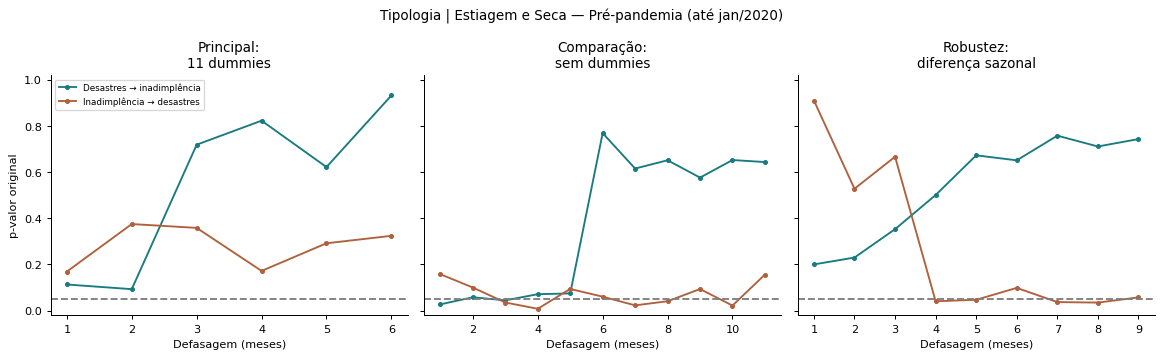

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
372,Principal: 11 dummies,AIC,Desastres → inadimplência,5,0.705285,0.621824,0.847699,1.000000,0.753083,4.301776e-02,79,5,57,5
373,Principal: 11 dummies,AIC,Inadimplência → desastres,5,1.264765,0.291723,0.570002,1.000000,0.391385,9.616760e-02,79,5,57,5
374,Principal: 11 dummies,BIC,Desastres → inadimplência,2,2.462837,0.092990,0.570474,1.000000,0.184118,6.184188e-02,82,2,66,2
375,Principal: 11 dummies,BIC,Inadimplência → desastres,2,0.995393,0.375057,0.672813,1.000000,0.487837,1.084420e-01,82,2,66,2
376,Comparação: sem dummies,AIC,Desastres → inadimplência,7,0.768957,0.615391,0.847699,1.000000,0.633922,4.185470e-02,77,7,62,7
377,Comparação: sem dummies,AIC,Inadimplência → desastres,7,2.542920,0.022854,0.155711,0.940327,0.001350,2.491576e-17,77,7,62,7
378,Comparação: sem dummies,BIC,Desastres → inadimplência,1,5.055238,0.027303,0.320809,1.000000,0.036252,1.618106e-01,83,1,80,1
379,Comparação: sem dummies,BIC,Inadimplência → desastres,1,2.033500,0.157757,0.402965,1.000000,0.145249,1.319255e-01,83,1,80,1
380,Robustez: diferença sazonal,AIC,Desastres → inadimplência,4,0.847751,0.500690,0.837319,1.000000,0.586579,3.665637e-01,68,4,59,4
381,Robustez: diferença sazonal,AIC,Inadimplência → desastres,4,2.676047,0.040433,0.209000,1.000000,0.080270,7.966373e-03,68,4,59,4


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
372,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.872927,5.070483e-02,2.365546e-02,-0.193056,False,0.056264,0.411997,Inconclusiva: nenhum rejeita,Estacionária: convergente
373,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.872927,5.070483e-02,1.965142e-02,-0.004640,False,0.015171,0.904246,Inconclusiva: nenhum rejeita,Estacionária: convergente
374,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.633533,7.717866e-04,1.074936e-02,-0.163510,False,0.411704,0.750803,Inconclusiva: nenhum rejeita,Estacionária: convergente
375,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.633533,7.717866e-04,3.001250e-03,0.058248,False,0.073388,0.584537,Inconclusiva: nenhum rejeita,Estacionária: convergente
376,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.966592,2.476303e-01,9.338252e-02,0.055212,False,0.535858,0.262249,Inconclusiva: nenhum rejeita,Estacionária: convergente
377,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.966592,2.476303e-01,1.353715e-02,0.118269,False,0.065239,0.961167,Inconclusiva: nenhum rejeita,Estacionária: convergente
378,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.307314,1.557107e-07,9.694815e-07,0.300017,True,0.473126,0.125912,Inconclusiva: nenhum rejeita,Estacionária: convergente
379,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.307314,1.557107e-07,4.408123e-04,0.233521,True,0.520958,0.525157,Inconclusiva: nenhum rejeita,Estacionária: convergente
380,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.803627,4.925762e-02,6.862381e-03,-0.370430,True,0.989221,0.798199,Inconclusiva: nenhum rejeita,Estacionária: convergente
381,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.803627,4.925762e-02,1.430911e-02,-0.128086,False,0.780209,0.684030,Inconclusiva: nenhum rejeita,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 5, p=0.6218, BH=0.8477, n=79; BIC: lag 2, p=0.09299, BH=0.5705, n=82.

**Comparação: sem dummies** — AIC: lag 7, p=0.6154, BH=0.8477, n=77; BIC: lag 1, p=0.0273, BH=0.3208, n=83.

**Robustez: diferença sazonal** — AIC: lag 4, p=0.5007, BH=0.8373, n=68; BIC: lag 1, p=0.2002, BH=0.7136, n=71.

Na direção principal, 1/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 2 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 8/12 linhas; 5 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Neste recorte, a estacionariedade da inadimplência transformada não tem confirmação conjunta. Os testes Granger são exploratórios; a ausência de rejeição do ADF não demonstra não estacionariedade, mas a limitação impede uma conclusão robusta.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Granizo — Total (2013–2024)

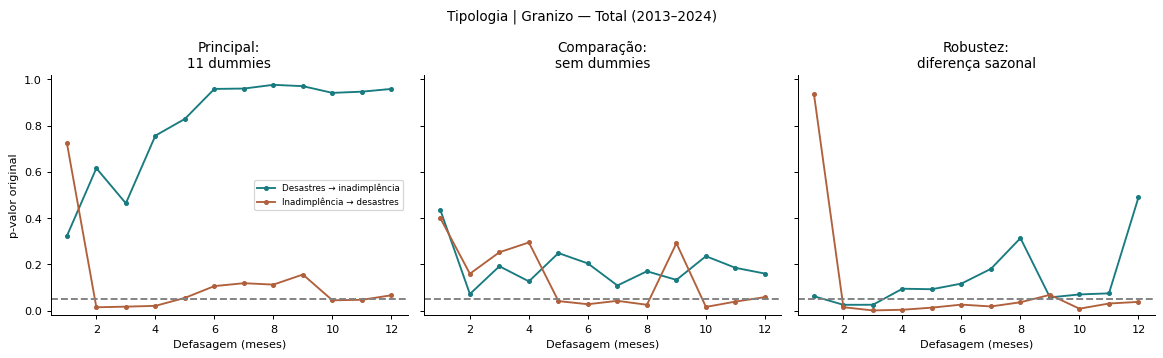

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
132,Principal: 11 dummies,AIC,Desastres → inadimplência,3,0.860163,0.463838,0.837319,1.000000,0.437323,2.829348e-01,140,3,122,3
133,Principal: 11 dummies,AIC,Inadimplência → desastres,3,3.519392,0.017198,0.127638,0.770798,0.020070,1.458172e-02,140,3,122,3
134,Principal: 11 dummies,BIC,Desastres → inadimplência,2,0.487095,0.615570,0.847699,1.000000,0.629231,4.988946e-01,141,2,125,2
135,Principal: 11 dummies,BIC,Inadimplência → desastres,2,4.383872,0.014452,0.125782,0.759586,0.011420,5.746308e-03,141,2,125,2
136,Comparação: sem dummies,AIC,Desastres → inadimplência,12,1.438500,0.160059,0.659894,1.000000,0.388897,8.235703e-03,131,12,106,12
137,Comparação: sem dummies,AIC,Inadimplência → desastres,12,1.793114,0.058360,0.229486,1.000000,0.030058,4.224038e-12,131,12,106,12
138,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.614392,0.434472,0.830090,1.000000,0.408455,2.842443e-01,142,1,139,1
139,Comparação: sem dummies,BIC,Inadimplência → desastres,1,0.714123,0.399531,0.679775,1.000000,0.410260,4.642671e-01,142,1,139,1
140,Robustez: diferença sazonal,AIC,Desastres → inadimplência,12,0.963129,0.489314,0.837319,1.000000,0.705051,4.957734e-02,119,12,94,12
141,Robustez: diferença sazonal,AIC,Inadimplência → desastres,12,1.950737,0.037737,0.206237,1.000000,0.166566,9.459248e-10,119,12,94,12


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
132,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.741022,2.292914e-01,5.446121e-01,-0.044536,False,3.072244e-13,0.027385,Estacionária: convergente,Estacionária: convergente
133,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.741022,2.292914e-01,1.834068e-03,-0.042698,False,2.497106e-01,0.695056,Estacionária: convergente,Estacionária: convergente
134,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.666117,6.639817e-02,3.030283e-01,-0.043470,False,1.429658e-09,0.148850,Estacionária: convergente,Estacionária: convergente
135,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.666117,6.639817e-02,6.380371e-03,-0.048346,False,1.356396e-01,0.366935,Estacionária: convergente,Estacionária: convergente
136,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.971970,4.519910e-02,5.096776e-04,-0.014478,False,2.657668e-14,0.730350,Estacionária: convergente,Estacionária: convergente
137,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.971970,4.519910e-02,4.094127e-03,-0.145993,False,2.509668e-01,0.632282,Estacionária: convergente,Estacionária: convergente
138,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.462518,3.118405e-13,6.439909e-15,0.411169,True,2.446237e-04,0.236795,Estacionária: convergente,Estacionária: convergente
139,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.462518,3.118405e-13,3.385701e-03,0.258082,True,4.892256e-01,0.634215,Estacionária: convergente,Estacionária: convergente
140,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.968359,4.431330e-03,1.548593e-05,-0.132019,False,4.909328e-01,0.598140,Estacionária: convergente,Estacionária: convergente
141,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.968359,4.431330e-03,3.015690e-04,-0.251007,True,4.253435e-01,0.356010,Estacionária: convergente,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 3, p=0.4638, BH=0.8373, n=140; BIC: lag 2, p=0.6156, BH=0.8477, n=141.

**Comparação: sem dummies** — AIC: lag 12, p=0.1601, BH=0.6599, n=131; BIC: lag 1, p=0.4345, BH=0.8301, n=142.

**Robustez: diferença sazonal** — AIC: lag 12, p=0.4893, BH=0.8373, n=119; BIC: lag 3, p=0.02537, BH=0.3138, n=128.

Na direção principal, 1/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 4 nominais e 1 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 8/12 linhas; 5 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Granizo — Pré-pandemia (até jan/2020)

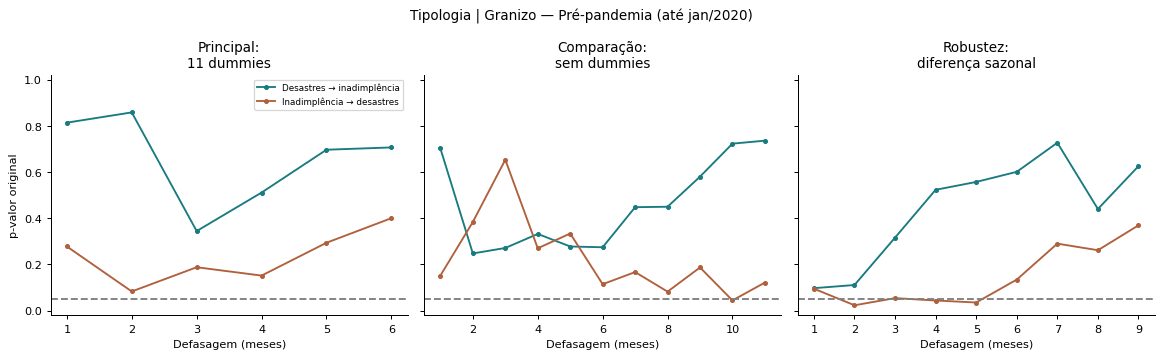

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
384,Principal: 11 dummies,AIC,Desastres → inadimplência,3,1.127928,0.344605,0.830090,1.000000,0.445662,5.419382e-05,81,3,63,3
385,Principal: 11 dummies,AIC,Inadimplência → desastres,3,1.644957,0.187968,0.435631,1.000000,0.312447,3.442499e-01,81,3,63,3
386,Principal: 11 dummies,BIC,Desastres → inadimplência,3,1.127928,0.344605,0.830090,1.000000,0.445662,5.419382e-05,81,3,63,3
387,Principal: 11 dummies,BIC,Inadimplência → desastres,3,1.644957,0.187968,0.435631,1.000000,0.312447,3.442499e-01,81,3,63,3
388,Comparação: sem dummies,AIC,Desastres → inadimplência,11,0.695764,0.736224,0.883025,1.000000,0.749507,4.706088e-06,73,11,50,11
389,Comparação: sem dummies,AIC,Inadimplência → desastres,11,1.620529,0.121713,0.364163,1.000000,0.110306,2.541065e-10,73,11,50,11
390,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.146866,0.702565,0.883025,1.000000,0.711400,5.966130e-01,83,1,80,1
391,Comparação: sem dummies,BIC,Inadimplência → desastres,1,2.093524,0.151832,0.399154,1.000000,0.225736,2.660901e-01,83,1,80,1
392,Robustez: diferença sazonal,AIC,Desastres → inadimplência,3,1.202475,0.316336,0.830090,1.000000,0.390178,1.208664e-01,69,3,62,3
393,Robustez: diferença sazonal,AIC,Inadimplência → desastres,3,2.685655,0.054193,0.229486,1.000000,0.056940,1.407276e-01,69,3,62,3


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
384,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.842574,2.992299e-02,2.433182e-01,-0.189761,False,0.078559,0.616798,Inconclusiva: nenhum rejeita,Estacionária: convergente
385,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.842574,2.992299e-02,2.330768e-03,-0.014703,False,0.554606,0.220371,Inconclusiva: nenhum rejeita,Estacionária: convergente
386,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.842574,2.992299e-02,2.433182e-01,-0.189761,False,0.078559,0.616798,Inconclusiva: nenhum rejeita,Estacionária: convergente
387,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.842574,2.992299e-02,2.330768e-03,-0.014703,False,0.554606,0.220371,Inconclusiva: nenhum rejeita,Estacionária: convergente
388,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.981659,1.841145e-02,1.917998e-02,-0.063785,False,0.001335,0.892289,Inconclusiva: nenhum rejeita,Estacionária: convergente
389,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.981659,1.841145e-02,2.732966e-04,-0.154139,False,0.838766,0.329986,Inconclusiva: nenhum rejeita,Estacionária: convergente
390,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.420614,8.615576e-07,9.170485e-09,0.373093,True,0.175223,0.401170,Inconclusiva: nenhum rejeita,Estacionária: convergente
391,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.420614,8.615576e-07,1.401019e-03,0.401107,True,0.828421,0.915240,Inconclusiva: nenhum rejeita,Estacionária: convergente
392,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.751264,4.326658e-04,1.703561e-02,-0.389366,True,0.887758,0.227201,Inconclusiva: nenhum rejeita,Estacionária: convergente
393,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.751264,4.326658e-04,1.045816e-04,-0.280694,True,0.807679,0.193218,Inconclusiva: nenhum rejeita,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 3, p=0.3446, BH=0.8301, n=81; BIC: lag 3, p=0.3446, BH=0.8301, n=81.

**Comparação: sem dummies** — AIC: lag 11, p=0.7362, BH=0.883, n=73; BIC: lag 1, p=0.7026, BH=0.883, n=83.

**Robustez: diferença sazonal** — AIC: lag 3, p=0.3163, BH=0.8301, n=69; BIC: lag 2, p=0.111, BH=0.5705, n=70.

Na direção principal, 0/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 1 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 12/12 linhas; 6 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Neste recorte, a estacionariedade da inadimplência transformada não tem confirmação conjunta. Os testes Granger são exploratórios; a ausência de rejeição do ADF não demonstra não estacionariedade, mas a limitação impede uma conclusão robusta.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Incêndio Florestal — Total (2013–2024)

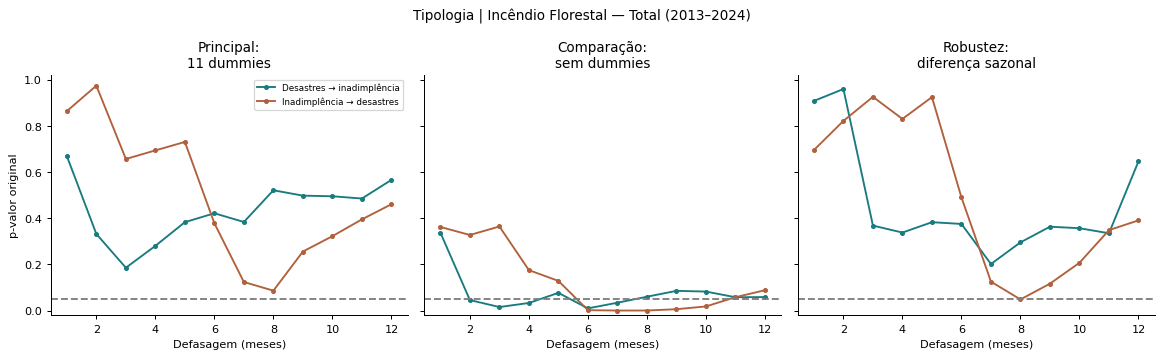

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
144,Principal: 11 dummies,AIC,Desastres → inadimplência,7,1.075627,0.383925,0.830090,1.000000,0.469015,1.756222e-01,136,7,110,7
145,Principal: 11 dummies,AIC,Inadimplência → desastres,7,1.668964,0.124001,0.364163,1.000000,0.057096,3.666063e-04,136,7,110,7
146,Principal: 11 dummies,BIC,Desastres → inadimplência,1,0.183044,0.669489,0.869226,1.000000,0.645271,6.027804e-01,142,1,128,1
147,Principal: 11 dummies,BIC,Inadimplência → desastres,1,0.029371,0.864195,0.927333,1.000000,0.872527,7.753300e-01,142,1,128,1
148,Comparação: sem dummies,AIC,Desastres → inadimplência,9,1.749358,0.085677,0.570474,1.000000,0.144719,3.762716e-02,134,9,115,9
149,Comparação: sem dummies,AIC,Inadimplência → desastres,9,2.741172,0.006163,0.096560,0.583116,0.004352,1.916675e-12,134,9,115,9
150,Comparação: sem dummies,BIC,Desastres → inadimplência,7,2.254922,0.034270,0.335559,1.000000,0.038040,2.379083e-02,136,7,121,0
151,Comparação: sem dummies,BIC,Inadimplência → desastres,7,4.167026,0.000384,0.038581,0.232985,0.000312,3.948717e-13,136,7,121,0
152,Robustez: diferença sazonal,AIC,Desastres → inadimplência,12,0.802853,0.646635,0.847699,1.000000,0.783352,4.020355e-03,119,12,94,12
153,Robustez: diferença sazonal,AIC,Inadimplência → desastres,12,1.073777,0.390973,0.679775,1.000000,0.394607,3.113275e-02,119,12,94,12


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
144,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.877778,6.014504e-01,1.013424e-01,-0.098194,False,9.249127e-13,0.064172,Estacionária: convergente,Estacionária: convergente
145,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.877778,6.014504e-01,1.787555e-02,-0.038298,False,1.366645e-02,0.618992,Estacionária: convergente,Estacionária: convergente
146,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.463723,3.391424e-02,1.633972e-01,-0.045010,False,1.780435e-06,0.516209,Estacionária: convergente,Estacionária: convergente
147,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.463723,3.391424e-02,1.683695e-02,-0.052089,False,3.491086e-02,0.220581,Estacionária: convergente,Estacionária: convergente
148,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.977531,1.760446e-02,1.322777e-03,0.100720,False,3.259657e-23,0.484115,Estacionária: convergente,Estacionária: convergente
149,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.977531,1.760446e-02,5.075733e-03,-0.044881,False,2.666210e-01,0.456309,Estacionária: convergente,Estacionária: convergente
150,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.944938,6.027357e-02,1.368200e-03,0.100411,False,6.242890e-25,0.253598,Estacionária: convergente,Estacionária: convergente
151,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.944938,6.027357e-02,3.233214e-02,0.002557,False,4.404856e-01,0.916333,Estacionária: convergente,Estacionária: convergente
152,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.972015,2.113104e-03,5.139753e-06,-0.138590,False,4.121944e-01,0.734131,Estacionária: convergente,Estacionária: convergente
153,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.972015,2.113104e-03,6.982913e-07,-0.181154,True,6.669582e-01,0.635205,Estacionária: convergente,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 7, p=0.3839, BH=0.8301, n=136; BIC: lag 1, p=0.6695, BH=0.8692, n=142.

**Comparação: sem dummies** — AIC: lag 9, p=0.08568, BH=0.5705, n=134; BIC: lag 7, p=0.03427, BH=0.3356, n=136 (ótimo incluindo zero: 0).

**Robustez: diferença sazonal** — AIC: lag 12, p=0.6466, BH=0.8477, n=119; BIC: lag 2, p=0.9599, BH=0.9808, n=129.

Na direção principal, 1/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 2 nominais e 1 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 8/12 linhas; 3 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Incêndio Florestal — Pré-pandemia (até jan/2020)

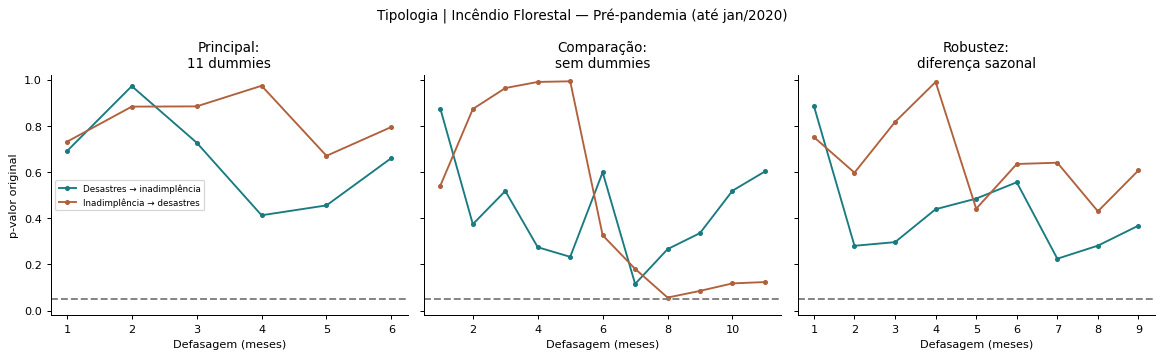

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
396,Principal: 11 dummies,AIC,Desastres → inadimplência,3,0.436582,0.727586,0.883025,1.0,0.804914,4.759033e-01,81,3,63,3
397,Principal: 11 dummies,AIC,Inadimplência → desastres,3,0.216336,0.884716,0.936524,1.0,0.881337,6.160424e-01,81,3,63,3
398,Principal: 11 dummies,BIC,Desastres → inadimplência,1,0.160103,0.690298,0.881631,1.0,0.755278,7.112466e-01,83,1,69,0
399,Principal: 11 dummies,BIC,Inadimplência → desastres,1,0.118890,0.731291,0.896667,1.0,0.803976,6.473431e-01,83,1,69,0
400,Comparação: sem dummies,AIC,Desastres → inadimplência,7,1.742212,0.115607,0.571768,1.0,0.095545,1.740574e-06,77,7,62,7
401,Comparação: sem dummies,AIC,Inadimplência → desastres,7,1.509114,0.180878,0.433738,1.0,0.224740,1.731595e-07,77,7,62,7
402,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.025261,0.874118,0.949633,1.0,0.892103,8.878901e-01,83,1,80,0
403,Comparação: sem dummies,BIC,Inadimplência → desastres,1,0.375080,0.541985,0.791097,1.0,0.573682,3.111929e-01,83,1,80,0
404,Robustez: diferença sazonal,AIC,Desastres → inadimplência,3,1.257758,0.296688,0.830090,1.0,0.149744,2.346276e-02,69,3,62,3
405,Robustez: diferença sazonal,AIC,Inadimplência → desastres,3,0.311013,0.817337,0.927333,1.0,0.819641,8.233863e-01,69,3,62,3


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
396,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.852185,1.907496e-01,2.322000e-01,-0.142183,False,0.020354,0.550109,Inconclusiva: nenhum rejeita,Estacionária: convergente
397,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.852185,1.907496e-01,2.805406e-03,-0.187040,False,0.016283,0.015042,Inconclusiva: nenhum rejeita,Estacionária: convergente
398,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.261316,9.861469e-05,9.351570e-03,-0.075591,False,0.789383,0.968350,Inconclusiva: nenhum rejeita,Estacionária: convergente
399,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.261316,9.861469e-05,1.545890e-04,-0.205538,False,0.141049,0.004314,Inconclusiva: nenhum rejeita,Estacionária: convergente
400,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.954295,9.665490e-02,3.960645e-02,-0.004926,False,0.254827,0.547636,Inconclusiva: nenhum rejeita,Estacionária: convergente
401,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.954295,9.665490e-02,5.077945e-02,-0.041167,False,0.825717,0.016520,Inconclusiva: nenhum rejeita,Estacionária: convergente
402,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.122791,1.019445e-06,2.101281e-08,0.364680,True,0.169333,0.183856,Inconclusiva: nenhum rejeita,Estacionária: convergente
403,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.122791,1.019445e-06,8.339100e-03,0.095250,False,0.184518,0.109442,Inconclusiva: nenhum rejeita,Estacionária: convergente
404,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.778635,1.386287e-02,1.317371e-02,-0.365362,True,0.822133,0.900338,Inconclusiva: nenhum rejeita,Estacionária: convergente
405,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.778635,1.386287e-02,2.011153e-04,-0.442067,True,0.515087,0.962318,Inconclusiva: nenhum rejeita,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 3, p=0.7276, BH=0.883, n=81; BIC: lag 1, p=0.6903, BH=0.8816, n=83 (ótimo incluindo zero: 0).

**Comparação: sem dummies** — AIC: lag 7, p=0.1156, BH=0.5718, n=77; BIC: lag 1, p=0.8741, BH=0.9496, n=83 (ótimo incluindo zero: 0).

**Robustez: diferença sazonal** — AIC: lag 3, p=0.2967, BH=0.8301, n=69; BIC: lag 1, p=0.8861, BH=0.9496, n=71 (ótimo incluindo zero: 0).

Na direção principal, 0/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 0 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 8/12 linhas; 5 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Neste recorte, a estacionariedade da inadimplência transformada não tem confirmação conjunta. Os testes Granger são exploratórios; a ausência de rejeição do ADF não demonstra não estacionariedade, mas a limitação impede uma conclusão robusta.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Inundações — Total (2013–2024)

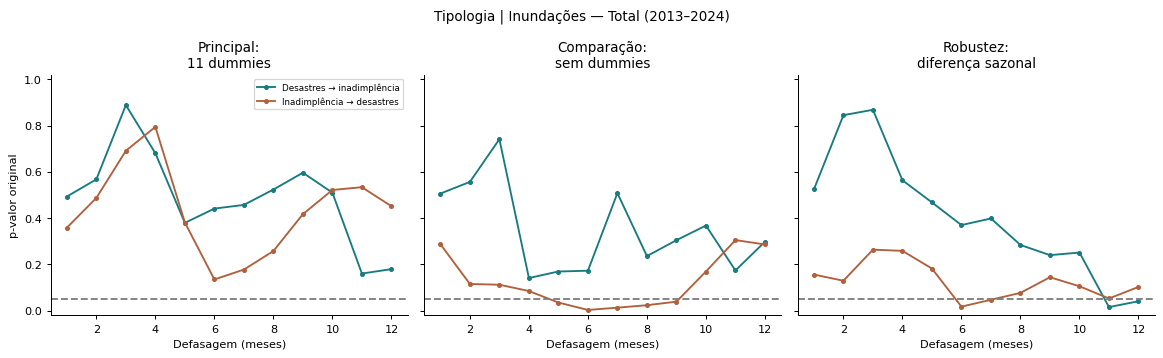

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
156,Principal: 11 dummies,AIC,Desastres → inadimplência,6,0.981789,0.441012,0.835790,1.000000,0.661353,2.282624e-04,137,6,113,6
157,Principal: 11 dummies,AIC,Inadimplência → desastres,6,1.670120,0.134733,0.375552,1.000000,0.102036,2.187399e-03,137,6,113,6
158,Principal: 11 dummies,BIC,Desastres → inadimplência,1,0.472685,0.492999,0.837319,1.000000,0.470263,3.413153e-01,142,1,128,1
159,Principal: 11 dummies,BIC,Inadimplência → desastres,1,0.850129,0.358250,0.652627,1.000000,0.423262,2.027259e-01,142,1,128,1
160,Comparação: sem dummies,AIC,Desastres → inadimplência,7,0.901284,0.507944,0.837319,1.000000,0.311152,5.685876e-02,136,7,121,7
161,Comparação: sem dummies,AIC,Inadimplência → desastres,7,2.683066,0.012842,0.123114,0.743475,0.006589,5.156008e-07,136,7,121,7
162,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.444663,0.505986,0.837319,1.000000,0.476206,4.072304e-01,142,1,139,0
163,Comparação: sem dummies,BIC,Inadimplência → desastres,1,1.141679,0.287150,0.567061,1.000000,0.325012,2.050703e-01,142,1,139,0
164,Robustez: diferença sazonal,AIC,Desastres → inadimplência,12,1.927479,0.040471,0.362610,1.000000,0.103489,1.780224e-07,119,12,94,12
165,Robustez: diferença sazonal,AIC,Inadimplência → desastres,12,1.608406,0.102341,0.343572,1.000000,0.031097,2.749863e-04,119,12,94,12


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
156,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.825503,1.650455e-01,2.412004e-01,-0.092235,False,1.332677e-14,0.050420,Estacionária: convergente,Estacionária: convergente
157,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.825503,1.650455e-01,2.098459e-02,-0.130339,False,4.126409e-02,0.117218,Estacionária: convergente,Estacionária: convergente
158,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.454464,2.632994e-02,1.270190e-01,-0.057024,False,1.241705e-06,0.444973,Estacionária: convergente,Estacionária: convergente
159,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.454464,2.632994e-02,2.524192e-03,-0.188424,True,8.049979e-02,0.264743,Estacionária: convergente,Estacionária: convergente
160,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.933106,7.178634e-03,3.899123e-03,0.177701,True,1.437088e-19,0.317502,Estacionária: convergente,Estacionária: convergente
161,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.933106,7.178634e-03,2.522232e-02,-0.025971,False,8.998940e-01,0.194790,Estacionária: convergente,Estacionária: convergente
162,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.163369,7.093769e-12,1.892517e-13,0.392320,True,3.978561e-04,0.226265,Estacionária: convergente,Estacionária: convergente
163,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.163369,7.093769e-12,8.139572e-04,0.122817,False,7.906598e-01,0.587208,Estacionária: convergente,Estacionária: convergente
164,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.978416,1.063318e-04,1.173873e-06,-0.140377,False,4.876901e-01,0.983566,Estacionária: convergente,Estacionária: convergente
165,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.978416,1.063318e-04,3.758848e-08,-0.219891,True,1.238204e-01,0.623934,Estacionária: convergente,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 6, p=0.441, BH=0.8358, n=137; BIC: lag 1, p=0.493, BH=0.8373, n=142.

**Comparação: sem dummies** — AIC: lag 7, p=0.5079, BH=0.8373, n=136; BIC: lag 1, p=0.506, BH=0.8373, n=142 (ótimo incluindo zero: 0).

**Robustez: diferença sazonal** — AIC: lag 12, p=0.04047, BH=0.3626, n=119; BIC: lag 1, p=0.5242, BH=0.8379, n=130.

Na direção principal, 1/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 1 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 10/12 linhas; 6 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Inundações — Pré-pandemia (até jan/2020)

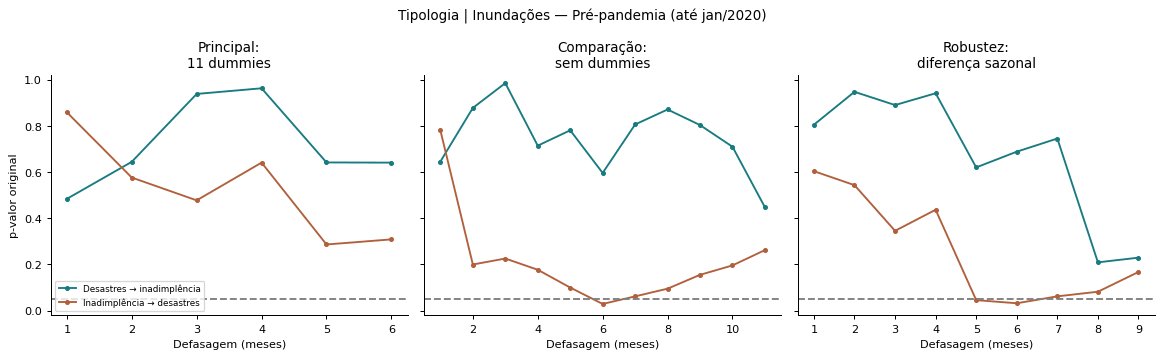

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
408,Principal: 11 dummies,AIC,Desastres → inadimplência,6,0.712463,0.641052,0.847699,1.0,0.686380,0.000080,78,6,54,6
409,Principal: 11 dummies,AIC,Inadimplência → desastres,6,1.223918,0.308583,0.589569,1.0,0.425248,0.000184,78,6,54,6
410,Principal: 11 dummies,BIC,Desastres → inadimplência,1,0.494859,0.484135,0.837319,1.0,0.520458,0.299258,83,1,69,0
411,Principal: 11 dummies,BIC,Inadimplência → desastres,1,0.031726,0.859153,0.927333,1.0,0.873065,0.826277,83,1,69,0
412,Comparação: sem dummies,AIC,Desastres → inadimplência,6,0.769794,0.596411,0.847699,1.0,0.491056,0.268567,78,6,65,6
413,Comparação: sem dummies,AIC,Inadimplência → desastres,6,2.531417,0.028995,0.171772,1.0,0.027280,0.000002,78,6,65,6
414,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.212857,0.645789,0.847699,1.0,0.655096,0.582391,83,1,80,0
415,Comparação: sem dummies,BIC,Inadimplência → desastres,1,0.077934,0.780838,0.908400,1.0,0.828541,0.781237,83,1,80,0
416,Robustez: diferença sazonal,AIC,Desastres → inadimplência,5,0.707411,0.620316,0.847699,1.0,0.756638,0.194550,67,5,56,5
417,Robustez: diferença sazonal,AIC,Inadimplência → desastres,5,2.436310,0.045578,0.214218,1.0,0.057411,0.000019,67,5,56,5


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
408,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.895127,0.175339,3.196329e-03,-0.202924,False,0.005784,0.720169,Inconclusiva: nenhum rejeita,Estacionária: convergente
409,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.895127,0.175339,3.386503e-02,-0.132921,False,0.288950,0.153783,Inconclusiva: nenhum rejeita,Estacionária: convergente
410,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.331566,0.076487,4.485071e-03,-0.095776,False,0.661248,0.894097,Inconclusiva: nenhum rejeita,Estacionária: convergente
411,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.331566,0.076487,5.672501e-02,-0.139151,False,0.278992,0.750638,Inconclusiva: nenhum rejeita,Estacionária: convergente
412,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.945563,0.385414,3.143952e-02,0.067491,False,0.194186,0.688973,Inconclusiva: nenhum rejeita,Estacionária: convergente
413,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.945563,0.385414,5.512668e-02,-0.040784,False,0.215140,0.398146,Inconclusiva: nenhum rejeita,Estacionária: convergente
414,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.227292,0.000055,4.117327e-08,0.360185,True,0.114810,0.542031,Inconclusiva: nenhum rejeita,Estacionária: convergente
415,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.227292,0.000055,3.476334e-02,0.129271,False,0.406347,0.656443,Inconclusiva: nenhum rejeita,Estacionária: convergente
416,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.839814,0.033072,1.443438e-03,-0.373833,True,0.808659,0.262768,Inconclusiva: nenhum rejeita,Estacionária: convergente
417,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.839814,0.033072,2.223015e-02,-0.250326,True,0.010738,0.754001,Inconclusiva: nenhum rejeita,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 6, p=0.6411, BH=0.8477, n=78; BIC: lag 1, p=0.4841, BH=0.8373, n=83 (ótimo incluindo zero: 0).

**Comparação: sem dummies** — AIC: lag 6, p=0.5964, BH=0.8477, n=78; BIC: lag 1, p=0.6458, BH=0.8477, n=83 (ótimo incluindo zero: 0).

**Robustez: diferença sazonal** — AIC: lag 5, p=0.6203, BH=0.8477, n=67; BIC: lag 1, p=0.8053, BH=0.9186, n=71 (ótimo incluindo zero: 0).

Na direção principal, 0/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 2 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 6/12 linhas; 5 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Neste recorte, a estacionariedade da inadimplência transformada não tem confirmação conjunta. Os testes Granger são exploratórios; a ausência de rejeição do ADF não demonstra não estacionariedade, mas a limitação impede uma conclusão robusta.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Movimento de Massa — Total (2013–2024)

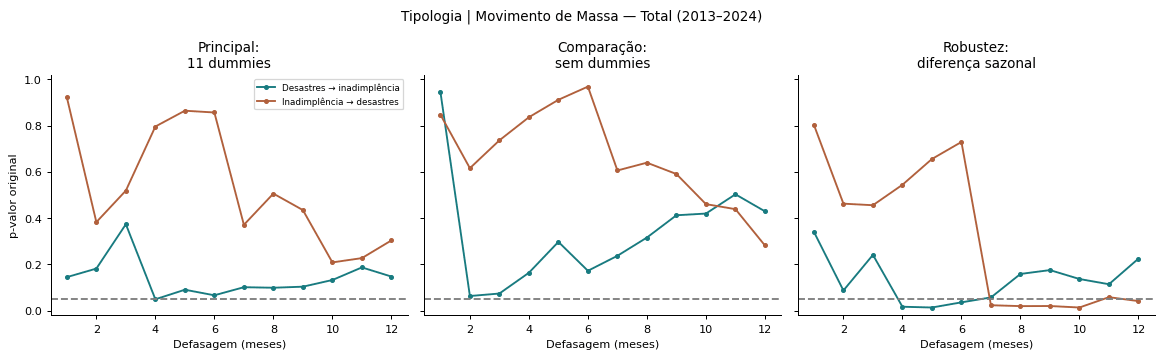

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
168,Principal: 11 dummies,AIC,Desastres → inadimplência,4,2.460722,0.049021,0.397242,1.0,0.245369,0.000012,139,4,119,4
169,Principal: 11 dummies,AIC,Inadimplência → desastres,4,0.417498,0.795753,0.916536,1.0,0.807592,0.387632,139,4,119,4
170,Principal: 11 dummies,BIC,Desastres → inadimplência,2,1.729130,0.181656,0.688533,1.0,0.343226,0.229763,141,2,125,2
171,Principal: 11 dummies,BIC,Inadimplência → desastres,2,0.968352,0.382538,0.675913,1.0,0.282937,0.055910,141,2,125,2
172,Comparação: sem dummies,AIC,Desastres → inadimplência,8,1.181703,0.315853,0.830090,1.0,0.246646,0.009796,135,8,118,8
173,Comparação: sem dummies,AIC,Inadimplência → desastres,8,0.758959,0.639449,0.830224,1.0,0.700913,0.075422,135,8,118,8
174,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.004551,0.946313,0.980763,1.0,0.949233,0.919912,142,1,139,1
175,Comparação: sem dummies,BIC,Inadimplência → desastres,1,0.037142,0.847459,0.927333,1.0,0.859929,0.759936,142,1,139,1
176,Robustez: diferença sazonal,AIC,Desastres → inadimplência,12,1.312039,0.224816,0.756878,1.0,0.523950,0.005829,119,12,94,12
177,Robustez: diferença sazonal,AIC,Inadimplência → desastres,12,1.922306,0.041105,0.209000,1.0,0.133677,0.000004,119,12,94,12


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
168,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.796702,4.392758e-01,6.671458e-02,-0.077359,False,3.736554e-07,0.039158,Estacionária: convergente,Estacionária: convergente
169,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.796702,4.392758e-01,1.140694e-01,-0.082342,False,7.582439e-02,0.120706,Estacionária: convergente,Estacionária: convergente
170,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.669156,7.879806e-02,6.493404e-02,-0.059261,False,1.249434e-05,0.056091,Estacionária: convergente,Estacionária: convergente
171,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.669156,7.879806e-02,2.216247e-01,-0.034289,False,6.113985e-02,0.055041,Estacionária: convergente,Estacionária: convergente
172,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.927758,1.665341e-02,1.008678e-03,0.208990,True,3.087362e-21,0.319752,Estacionária: convergente,Estacionária: convergente
173,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.927758,1.665341e-02,1.250316e-03,0.125947,False,3.761409e-01,0.462780,Estacionária: convergente,Estacionária: convergente
174,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.492313,2.719993e-10,3.426199e-14,0.404019,True,2.749794e-04,0.053257,Estacionária: convergente,Estacionária: convergente
175,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.492313,2.719993e-10,3.543143e-03,0.163334,False,6.699616e-01,0.881794,Estacionária: convergente,Estacionária: convergente
176,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.973240,9.260851e-05,2.272383e-06,-0.198955,True,5.997499e-01,0.956682,Estacionária: convergente,Estacionária: convergente
177,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.973240,9.260851e-05,6.209706e-07,-0.179151,False,7.611894e-01,0.335511,Estacionária: convergente,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 4, p=0.04902, BH=0.3972, n=139; BIC: lag 2, p=0.1817, BH=0.6885, n=141.

**Comparação: sem dummies** — AIC: lag 8, p=0.3159, BH=0.8301, n=135; BIC: lag 1, p=0.9463, BH=0.9808, n=142.

**Robustez: diferença sazonal** — AIC: lag 12, p=0.2248, BH=0.7569, n=119; BIC: lag 2, p=0.08704, BH=0.5705, n=129.

Na direção principal, 1/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 1 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 8/12 linhas; 5 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Movimento de Massa — Pré-pandemia (até jan/2020)

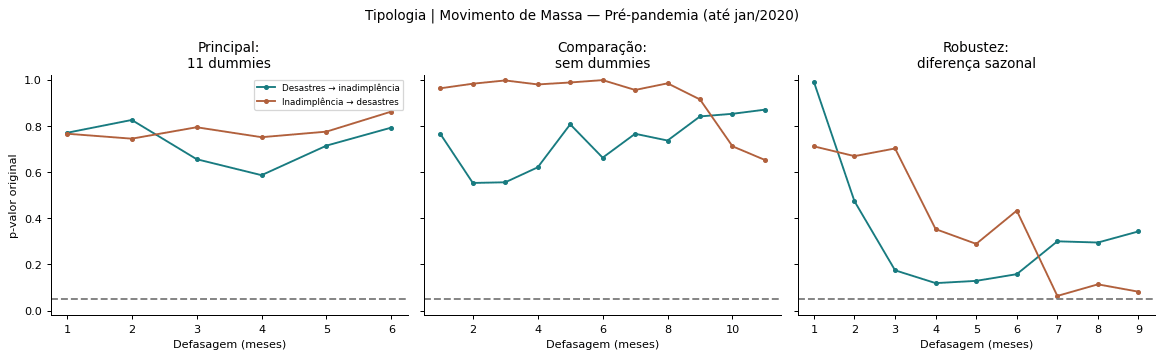

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
420,Principal: 11 dummies,AIC,Desastres → inadimplência,4,0.712388,0.586701,0.847699,1.0,0.741842,0.023219,80,4,60,4
421,Principal: 11 dummies,AIC,Inadimplência → desastres,4,0.478642,0.751255,0.896667,1.0,0.815559,0.434463,80,4,60,4
422,Principal: 11 dummies,BIC,Desastres → inadimplência,2,0.191838,0.825899,0.927162,1.0,0.881876,0.735742,82,2,66,2
423,Principal: 11 dummies,BIC,Inadimplência → desastres,2,0.295906,0.744839,0.896667,1.0,0.677282,0.342913,82,2,66,2
424,Comparação: sem dummies,AIC,Desastres → inadimplência,8,0.644878,0.736855,0.883025,1.0,0.801351,0.076098,76,8,59,8
425,Comparação: sem dummies,AIC,Inadimplência → desastres,8,0.226665,0.984597,0.993048,1.0,0.996176,0.537685,76,8,59,8
426,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.089806,0.765201,0.899508,1.0,0.781170,0.725779,83,1,80,1
427,Comparação: sem dummies,BIC,Inadimplência → desastres,1,0.002152,0.963120,0.979797,1.0,0.969080,0.946241,83,1,80,1
428,Robustez: diferença sazonal,AIC,Desastres → inadimplência,4,1.918606,0.119220,0.571768,1.0,0.117023,0.000012,68,4,59,4
429,Robustez: diferença sazonal,AIC,Inadimplência → desastres,4,1.125694,0.353145,0.648353,1.0,0.418251,0.000336,68,4,59,4


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
420,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.845479,7.592946e-01,1.621385e-01,-0.108997,False,0.169166,0.592273,Inconclusiva: nenhum rejeita,Estacionária: convergente
421,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.845479,7.592946e-01,1.972841e-01,-0.075389,False,0.413513,0.045445,Inconclusiva: nenhum rejeita,Estacionária: convergente
422,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.690477,7.928498e-02,7.509042e-04,-0.103144,False,0.819067,0.582109,Inconclusiva: nenhum rejeita,Estacionária: convergente
423,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.690477,7.928498e-02,3.547800e-01,-0.060217,False,0.339851,0.013777,Inconclusiva: nenhum rejeita,Estacionária: convergente
424,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.957063,4.197168e-01,6.542497e-03,0.098106,False,0.085348,0.804011,Inconclusiva: nenhum rejeita,Estacionária: convergente
425,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.957063,4.197168e-01,1.181428e-02,0.059107,False,0.490195,0.644256,Inconclusiva: nenhum rejeita,Estacionária: convergente
426,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.559161,8.816071e-05,1.688884e-08,0.366507,True,0.162272,0.648296,Inconclusiva: nenhum rejeita,Estacionária: convergente
427,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.559161,8.816071e-05,1.285799e-02,0.130162,False,0.657957,0.505060,Inconclusiva: nenhum rejeita,Estacionária: convergente
428,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.875757,4.881761e-03,2.781830e-03,-0.391932,True,0.786652,0.993383,Inconclusiva: nenhum rejeita,Estacionária: convergente
429,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.875757,4.881761e-03,4.754249e-04,-0.317748,True,0.812873,0.316064,Inconclusiva: nenhum rejeita,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 4, p=0.5867, BH=0.8477, n=80; BIC: lag 2, p=0.8259, BH=0.9272, n=82.

**Comparação: sem dummies** — AIC: lag 8, p=0.7369, BH=0.883, n=76; BIC: lag 1, p=0.7652, BH=0.8995, n=83.

**Robustez: diferença sazonal** — AIC: lag 4, p=0.1192, BH=0.5718, n=68; BIC: lag 1, p=0.9905, BH=0.9947, n=71.

Na direção principal, 0/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 0 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 6/12 linhas; 5 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Neste recorte, a estacionariedade da inadimplência transformada não tem confirmação conjunta. Os testes Granger são exploratórios; a ausência de rejeição do ADF não demonstra não estacionariedade, mas a limitação impede uma conclusão robusta.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Onda de Calor e Baixa Umidade — Total (2013–2024)

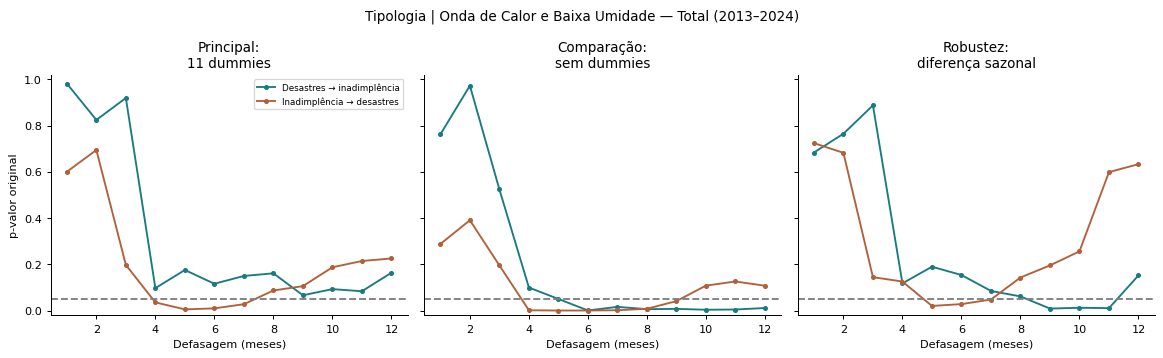

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
180,Principal: 11 dummies,AIC,Desastres → inadimplência,5,1.564174,0.175668,0.676755,1.000000,0.259083,5.100093e-03,138,5,116,5
181,Principal: 11 dummies,AIC,Inadimplência → desastres,5,3.514153,0.005395,0.090551,0.546828,0.294558,1.781636e-04,138,5,116,5
182,Principal: 11 dummies,BIC,Desastres → inadimplência,1,0.000537,0.981555,0.990867,1.000000,0.982665,9.780838e-01,142,1,128,1
183,Principal: 11 dummies,BIC,Inadimplência → desastres,1,0.276218,0.600100,0.806519,1.000000,0.746222,6.677289e-01,142,1,128,1
184,Comparação: sem dummies,AIC,Desastres → inadimplência,12,2.320007,0.011267,0.258566,1.000000,0.081431,3.824876e-04,131,12,106,12
185,Comparação: sem dummies,AIC,Inadimplência → desastres,12,1.582641,0.107629,0.351287,1.000000,0.704522,3.974462e-03,131,12,106,12
186,Comparação: sem dummies,BIC,Desastres → inadimplência,6,4.237172,0.000648,0.152185,0.919033,0.001203,2.524919e-10,137,6,124,6
187,Comparação: sem dummies,BIC,Inadimplência → desastres,6,4.384023,0.000473,0.038581,0.232985,0.243901,4.434119e-04,137,6,124,6
188,Robustez: diferença sazonal,AIC,Desastres → inadimplência,12,1.463191,0.152186,0.655870,1.000000,0.287495,3.958309e-06,119,12,94,12
189,Robustez: diferença sazonal,AIC,Inadimplência → desastres,12,0.816355,0.633113,0.826564,1.000000,0.708129,2.511742e-02,119,12,94,12


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
180,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.844608,4.190031e-01,3.827569e-02,-0.076371,False,2.038222e-14,0.058619,Estacionária: convergente,Estacionária: convergente
181,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.844608,4.190031e-01,1.771258e-03,0.000573,False,2.349543e-04,0.478016,Estacionária: convergente,Estacionária: convergente
182,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.469896,4.835817e-02,1.614576e-01,-0.042209,False,2.273314e-06,0.496209,Estacionária: convergente,Estacionária: convergente
183,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.469896,4.835817e-02,2.883184e-01,0.008433,False,3.280772e-16,0.252359,Estacionária: convergente,Estacionária: convergente
184,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.976417,9.359284e-03,9.788136e-03,-0.016608,False,4.990040e-07,0.647967,Estacionária: convergente,Estacionária: convergente
185,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.976417,9.359284e-03,2.210669e-04,-0.153317,False,3.506220e-05,0.219969,Estacionária: convergente,Estacionária: convergente
186,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.939779,6.421428e-02,4.539476e-03,0.123271,False,3.915629e-19,0.241220,Estacionária: convergente,Estacionária: convergente
187,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.939779,6.421428e-02,5.512111e-03,0.041866,False,7.934639e-09,0.099568,Estacionária: convergente,Estacionária: convergente
188,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.969363,1.285499e-04,1.075558e-04,-0.182014,True,4.275795e-01,0.903048,Estacionária: convergente,Estacionária: convergente
189,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.969363,1.285499e-04,6.186910e-07,-0.201974,True,1.293051e-02,0.250325,Estacionária: convergente,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 5, p=0.1757, BH=0.6768, n=138; BIC: lag 1, p=0.9816, BH=0.9909, n=142.

**Comparação: sem dummies** — AIC: lag 12, p=0.01127, BH=0.2586, n=131; BIC: lag 6, p=0.0006476, BH=0.1522, n=137.

**Robustez: diferença sazonal** — AIC: lag 12, p=0.1522, BH=0.6559, n=119; BIC: lag 1, p=0.6834, BH=0.8776, n=130.

Na direção principal, 2/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 2 nominais e 1 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 8/12 linhas; 4 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Onda de Calor e Baixa Umidade — Pré-pandemia (até jan/2020)

,Período,Chave,Nível,Categoria,Motivo
0,Pré-pandemia (até jan/2020),Tipologia | Onda de Calor e Baixa Umidade,Tipologia,Onda de Calor e Baixa Umidade,Constante ou rara (<12 meses positivos ou <24 protocolos); in...


### Tipologia | Onda de Frio — Total (2013–2024)

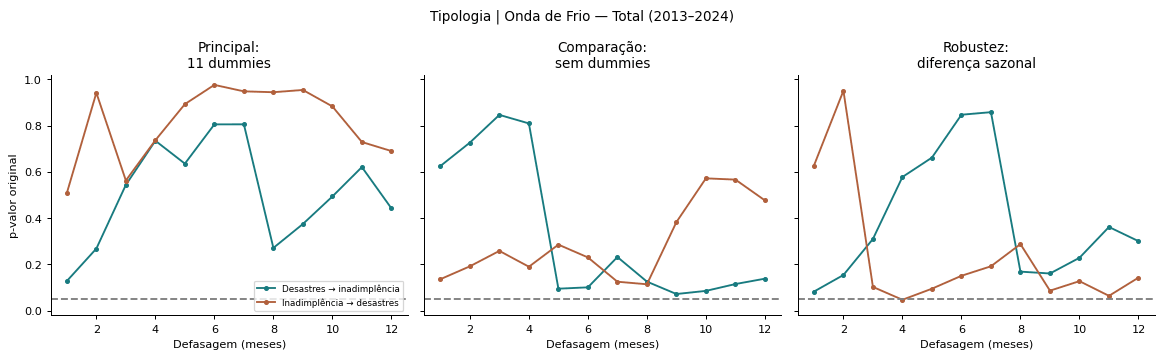

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
192,Principal: 11 dummies,AIC,Desastres → inadimplência,4,0.501885,0.734392,0.883025,1.0,0.835659,4.530684e-01,139,4,119,4
193,Principal: 11 dummies,AIC,Inadimplência → desastres,4,0.499167,0.736375,0.896667,1.0,0.690511,3.339319e-01,139,4,119,4
194,Principal: 11 dummies,BIC,Desastres → inadimplência,2,1.330521,0.268057,0.818095,1.0,0.212213,7.798207e-02,141,2,125,2
195,Principal: 11 dummies,BIC,Inadimplência → desastres,2,0.060333,0.941478,0.966146,1.0,0.940231,8.486535e-01,141,2,125,2
196,Comparação: sem dummies,AIC,Desastres → inadimplência,12,1.492874,0.138142,0.649270,1.0,0.267726,3.784235e-08,131,12,106,12
197,Comparação: sem dummies,AIC,Inadimplência → desastres,12,0.976042,0.476380,0.748652,1.0,0.834967,3.368761e-02,131,12,106,12
198,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.240032,0.624955,0.847699,1.0,0.581767,5.585144e-01,142,1,139,0
199,Comparação: sem dummies,BIC,Inadimplência → desastres,1,2.250683,0.135823,0.375552,1.0,0.134184,1.181006e-01,142,1,139,0
200,Robustez: diferença sazonal,AIC,Desastres → inadimplência,12,1.192007,0.300296,0.830090,1.0,0.271114,3.074582e-06,119,12,94,12
201,Robustez: diferença sazonal,AIC,Inadimplência → desastres,12,1.487691,0.142527,0.389463,1.0,0.323577,4.932071e-08,119,12,94,12


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
192,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.769828,1.322318e-01,2.891558e-01,-0.063945,False,3.807966e-16,0.071068,Estacionária: convergente,Estacionária: convergente
193,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.769828,1.322318e-01,3.674399e-04,-0.173842,True,3.253717e-26,0.023783,Estacionária: convergente,Estacionária: convergente
194,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.662797,6.107409e-02,2.313235e-01,-0.051829,False,3.864854e-09,0.192932,Estacionária: convergente,Estacionária: convergente
195,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.662797,6.107409e-02,2.476088e-04,-0.206212,True,2.008023e-20,0.001988,Estacionária: convergente,Estacionária: convergente
196,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.971581,5.421130e-04,1.718822e-04,0.038244,False,6.174484e-13,0.660703,Estacionária: convergente,Estacionária: convergente
197,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.971581,5.421130e-04,7.555084e-06,-0.038878,False,8.038704e-140,0.942381,Estacionária: convergente,Estacionária: convergente
198,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.179093,3.889244e-10,1.893119e-14,0.407293,True,3.478356e-04,0.249679,Estacionária: convergente,Estacionária: convergente
199,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.179093,3.889244e-10,1.445686e-02,-0.035266,False,4.687153e-40,0.567419,Estacionária: convergente,Estacionária: convergente
200,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.980496,2.401509e-03,4.160352e-06,-0.170358,False,1.602552e-01,0.996210,Estacionária: convergente,Estacionária: convergente
201,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.980496,2.401509e-03,8.731667e-05,-0.096849,False,2.594107e-01,0.870572,Estacionária: convergente,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 4, p=0.7344, BH=0.883, n=139; BIC: lag 2, p=0.2681, BH=0.8181, n=141.

**Comparação: sem dummies** — AIC: lag 12, p=0.1381, BH=0.6493, n=131; BIC: lag 1, p=0.625, BH=0.8477, n=142 (ótimo incluindo zero: 0).

**Robustez: diferença sazonal** — AIC: lag 12, p=0.3003, BH=0.8301, n=119; BIC: lag 2, p=0.154, BH=0.6559, n=129.

Na direção principal, 0/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 0 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 8/12 linhas; 5 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Onda de Frio — Pré-pandemia (até jan/2020)

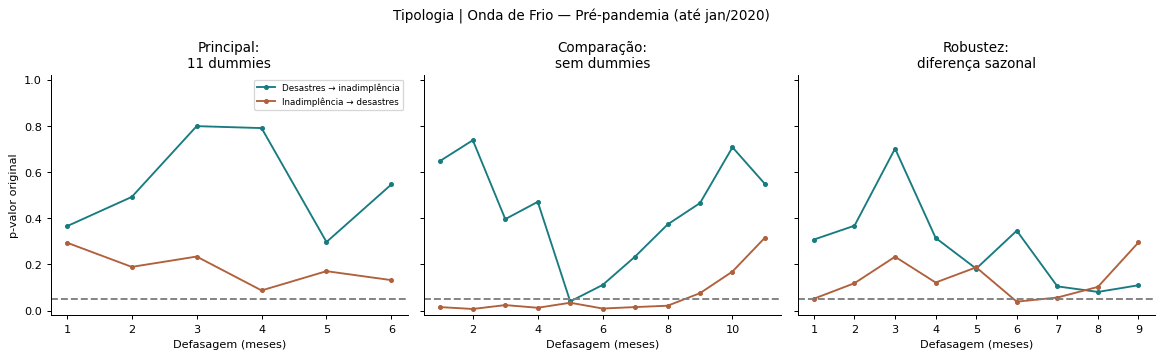

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
432,Principal: 11 dummies,AIC,Desastres → inadimplência,6,0.836991,0.546846,0.837887,1.000000,0.679187,1.692536e-01,78,6,54,6
433,Principal: 11 dummies,AIC,Inadimplência → desastres,6,1.728249,0.132111,0.375552,1.000000,0.317019,3.016254e-01,78,6,54,6
434,Principal: 11 dummies,BIC,Desastres → inadimplência,2,0.715895,0.492510,0.837319,1.000000,0.519011,3.341595e-01,82,2,66,0
435,Principal: 11 dummies,BIC,Inadimplência → desastres,2,1.706564,0.189399,0.435631,1.000000,0.200410,2.223331e-01,82,2,66,0
436,Comparação: sem dummies,AIC,Desastres → inadimplência,6,1.808375,0.111197,0.570474,1.000000,0.001562,1.832562e-17,78,6,65,6
437,Comparação: sem dummies,AIC,Inadimplência → desastres,6,3.141354,0.009124,0.112725,0.680739,0.144789,2.536986e-01,78,6,65,6
438,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.208447,0.649225,0.847699,1.000000,0.651598,4.394677e-01,83,1,80,0
439,Comparação: sem dummies,BIC,Inadimplência → desastres,1,6.155074,0.015201,0.127577,0.770427,0.052267,3.773422e-02,83,1,80,0
440,Robustez: diferença sazonal,AIC,Desastres → inadimplência,6,1.151207,0.346312,0.830090,1.000000,0.306068,2.570423e-03,66,6,53,6
441,Robustez: diferença sazonal,AIC,Inadimplência → desastres,6,2.414472,0.038876,0.207633,1.000000,0.239060,5.420833e-03,66,6,53,6


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
432,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.838431,0.083892,1.048576e-02,-0.211970,False,1.640318e-03,0.717283,Inconclusiva: nenhum rejeita,Estacionária: convergente
433,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.838431,0.083892,2.187287e-02,-0.106666,False,2.337329e-24,0.440423,Inconclusiva: nenhum rejeita,Estacionária: convergente
434,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.629003,0.104056,3.284596e-03,-0.104659,False,7.124905e-01,0.921320,Inconclusiva: nenhum rejeita,Estacionária: convergente
435,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.629003,0.104056,3.527597e-01,-0.090373,False,1.088276e-09,0.001586,Inconclusiva: nenhum rejeita,Estacionária: convergente
436,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.946955,0.105653,1.833002e-02,0.002848,False,5.686250e-03,0.885612,Inconclusiva: nenhum rejeita,Estacionária: convergente
437,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.946955,0.105653,1.185252e-01,0.029903,False,1.206586e-68,0.970576,Inconclusiva: nenhum rejeita,Estacionária: convergente
438,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.172738,0.000208,3.172435e-08,0.368655,True,1.127791e-01,0.464146,Inconclusiva: nenhum rejeita,Estacionária: convergente
439,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.172738,0.000208,1.765716e-01,0.036030,False,1.083085e-21,0.693500,Inconclusiva: nenhum rejeita,Estacionária: convergente
440,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.856624,0.019949,5.438680e-04,-0.382510,True,7.832934e-01,0.722852,Inconclusiva: nenhum rejeita,Inconclusiva: nenhum rejeita
441,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.856624,0.019949,2.919195e-02,-0.273218,True,1.578375e-07,0.938710,Inconclusiva: nenhum rejeita,Inconclusiva: nenhum rejeita


**Principal: 11 dummies** — AIC: lag 6, p=0.5468, BH=0.8379, n=78; BIC: lag 2, p=0.4925, BH=0.8373, n=82 (ótimo incluindo zero: 0).

**Comparação: sem dummies** — AIC: lag 6, p=0.1112, BH=0.5705, n=78; BIC: lag 1, p=0.6492, BH=0.8477, n=83 (ótimo incluindo zero: 0).

**Robustez: diferença sazonal** — AIC: lag 6, p=0.3463, BH=0.8301, n=66; BIC: lag 2, p=0.3679, BH=0.8301, n=70 (ótimo incluindo zero: 0).

Na direção principal, 0/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 3 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 6/12 linhas; 5 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Neste recorte, a estacionariedade da inadimplência transformada não tem confirmação conjunta. Os testes Granger são exploratórios; a ausência de rejeição do ADF não demonstra não estacionariedade, mas a limitação impede uma conclusão robusta.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Outros — Total (2013–2024)

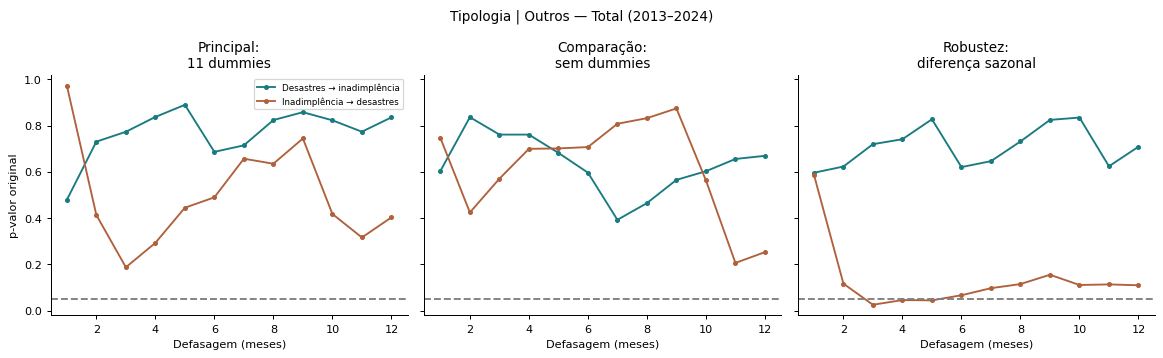

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
204,Principal: 11 dummies,AIC,Desastres → inadimplência,3,0.372454,0.773017,0.903776,1.0,0.821192,6.358400e-01,140,3,122,3
205,Principal: 11 dummies,AIC,Inadimplência → desastres,3,1.623503,0.187419,0.435631,1.0,0.150003,3.861794e-03,140,3,122,3
206,Principal: 11 dummies,BIC,Desastres → inadimplência,2,0.314942,0.730409,0.883025,1.0,0.759191,5.398042e-01,141,2,125,2
207,Principal: 11 dummies,BIC,Inadimplência → desastres,2,0.890055,0.413219,0.679775,1.0,0.480565,1.271405e-01,141,2,125,2
208,Comparação: sem dummies,AIC,Desastres → inadimplência,7,1.061617,0.392440,0.830090,1.0,0.813306,2.400591e-01,136,7,121,7
209,Comparação: sem dummies,AIC,Inadimplência → desastres,7,0.533449,0.807745,0.921457,1.0,0.922676,1.329593e-01,136,7,121,7
210,Comparação: sem dummies,BIC,Desastres → inadimplência,3,0.389303,0.760890,0.899508,1.0,0.746391,5.610316e-01,140,3,133,3
211,Comparação: sem dummies,BIC,Inadimplência → desastres,3,0.672885,0.570129,0.800250,1.0,0.602065,8.389193e-02,140,3,133,3
212,Robustez: diferença sazonal,AIC,Desastres → inadimplência,12,0.740528,0.708562,0.883025,1.0,0.851692,3.159217e-02,119,12,94,12
213,Robustez: diferença sazonal,AIC,Inadimplência → desastres,12,1.583703,0.109632,0.352924,1.0,0.036096,2.053934e-13,119,12,94,12


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
204,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.758271,1.346574e-01,3.477237e-01,-0.067295,False,4.355852e-18,0.036568,Estacionária: convergente,Estacionária: convergente
205,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.758271,1.346574e-01,1.680077e-03,0.084832,False,1.324135e-03,0.125878,Estacionária: convergente,Estacionária: convergente
206,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.661556,2.193330e-02,3.473011e-01,-0.053224,False,1.556646e-11,0.132765,Estacionária: convergente,Estacionária: convergente
207,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.661556,2.193330e-02,1.039081e-04,0.063450,False,4.765347e-02,0.049933,Estacionária: convergente,Estacionária: convergente
208,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.938781,8.850615e-03,1.084909e-03,0.214059,True,1.304895e-07,0.025366,Estacionária: convergente,Estacionária: convergente
209,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.938781,8.850615e-03,1.430516e-03,0.072608,False,4.959118e-02,0.118012,Estacionária: convergente,Estacionária: convergente
210,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.740589,1.129046e-08,3.351149e-10,0.388236,True,1.242276e-28,0.010923,Estacionária: convergente,Estacionária: convergente
211,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.740589,1.129046e-08,1.564621e-04,0.137105,False,2.185526e-02,0.147664,Estacionária: convergente,Estacionária: convergente
212,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.967206,1.434911e-02,1.915240e-05,-0.188086,True,2.170200e-01,0.967542,Estacionária: convergente,Estacionária: convergente
213,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.967206,1.434911e-02,3.694543e-03,-0.185987,True,2.165074e-01,0.509196,Estacionária: convergente,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 3, p=0.773, BH=0.9038, n=140; BIC: lag 2, p=0.7304, BH=0.883, n=141.

**Comparação: sem dummies** — AIC: lag 7, p=0.3924, BH=0.8301, n=136; BIC: lag 3, p=0.7609, BH=0.8995, n=140.

**Robustez: diferença sazonal** — AIC: lag 12, p=0.7086, BH=0.883, n=119; BIC: lag 2, p=0.6228, BH=0.8477, n=129.

Na direção principal, 0/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 0 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 10/12 linhas; 6 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Outros — Pré-pandemia (até jan/2020)

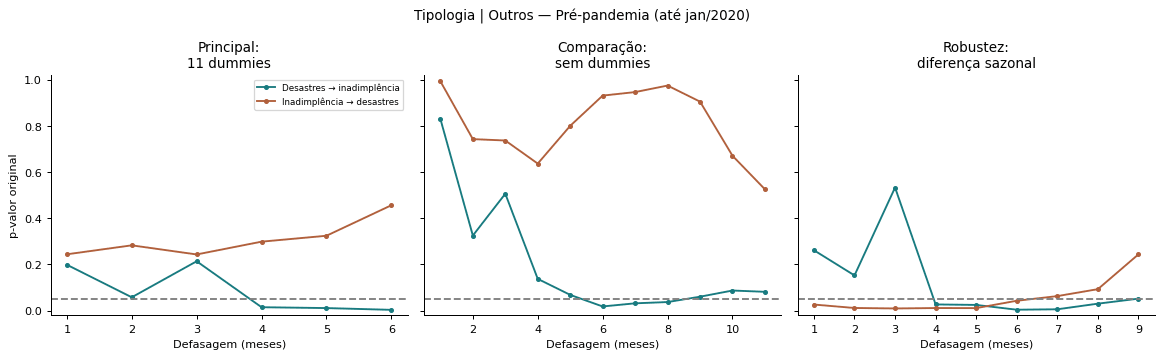

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
444,Principal: 11 dummies,AIC,Desastres → inadimplência,6,3.756385,0.003391,0.153274,0.92561,0.045395,2.056605e-08,78,6,54,6
445,Principal: 11 dummies,AIC,Inadimplência → desastres,6,0.966746,0.456507,0.730870,1.00000,0.408441,8.147918e-04,78,6,54,6
446,Principal: 11 dummies,BIC,Desastres → inadimplência,3,1.536219,0.213835,0.750017,1.00000,0.246250,3.254906e-02,81,3,63,3
447,Principal: 11 dummies,BIC,Inadimplência → desastres,3,1.426720,0.243328,0.506037,1.00000,0.239883,1.171984e-02,81,3,63,3
448,Comparação: sem dummies,AIC,Desastres → inadimplência,6,2.781636,0.018054,0.273314,1.00000,0.041322,1.103148e-09,78,6,65,6
449,Comparação: sem dummies,AIC,Inadimplência → desastres,6,0.306494,0.931383,0.966146,1.00000,0.887341,9.629242e-02,78,6,65,6
450,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.046217,0.830329,0.927162,1.00000,0.804130,7.885295e-01,83,1,80,0
451,Comparação: sem dummies,BIC,Inadimplência → desastres,1,0.000067,0.993501,0.993501,1.00000,0.993847,9.949000e-01,83,1,80,0
452,Robustez: diferença sazonal,AIC,Desastres → inadimplência,6,3.678701,0.003966,0.153274,0.92561,0.019206,2.325584e-08,66,6,53,6
453,Robustez: diferença sazonal,AIC,Inadimplência → desastres,6,2.362011,0.042751,0.209301,1.00000,0.086987,4.451946e-07,66,6,53,6


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
444,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.877403,0.369381,5.733201e-02,-0.200497,False,0.379366,0.433561,Inconclusiva: nenhum rejeita,Estacionária: convergente
445,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.877403,0.369381,4.483888e-02,-0.005661,False,0.167896,0.188894,Inconclusiva: nenhum rejeita,Estacionária: convergente
446,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.848271,0.075405,8.775410e-02,-0.191966,False,0.001654,0.335773,Inconclusiva: nenhum rejeita,Estacionária: convergente
447,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.848271,0.075405,9.300039e-02,0.028778,False,0.276699,0.122163,Inconclusiva: nenhum rejeita,Estacionária: convergente
448,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.933721,0.046909,9.853391e-03,0.183876,False,0.488305,0.307906,Inconclusiva: nenhum rejeita,Estacionária: convergente
449,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.933721,0.046909,1.524927e-02,0.038140,False,0.036374,0.439762,Inconclusiva: nenhum rejeita,Estacionária: convergente
450,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.427652,0.000002,3.130235e-08,0.360153,True,0.158732,0.598514,Inconclusiva: nenhum rejeita,Estacionária: convergente
451,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.427652,0.000002,1.542423e-02,-0.015459,False,0.688810,0.558673,Inconclusiva: nenhum rejeita,Estacionária: convergente
452,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.909057,0.004129,1.054949e-04,-0.465546,True,0.787609,0.664333,Inconclusiva: nenhum rejeita,Estacionária: convergente
453,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.909057,0.004129,5.229091e-04,-0.157403,False,0.306440,0.507245,Inconclusiva: nenhum rejeita,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 6, p=0.003391, BH=0.1533, n=78; BIC: lag 3, p=0.2138, BH=0.75, n=81.

**Comparação: sem dummies** — AIC: lag 6, p=0.01805, BH=0.2733, n=78; BIC: lag 1, p=0.8303, BH=0.9272, n=83 (ótimo incluindo zero: 0).

**Robustez: diferença sazonal** — AIC: lag 6, p=0.003966, BH=0.1533, n=66; BIC: lag 2, p=0.1526, BH=0.6559, n=70.

Na direção principal, 3/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 2 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 8/12 linhas; 3 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Neste recorte, a estacionariedade da inadimplência transformada não tem confirmação conjunta. Os testes Granger são exploratórios; a ausência de rejeição do ADF não demonstra não estacionariedade, mas a limitação impede uma conclusão robusta.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Rompimento/Colapso de barragens — Total (2013–2024)

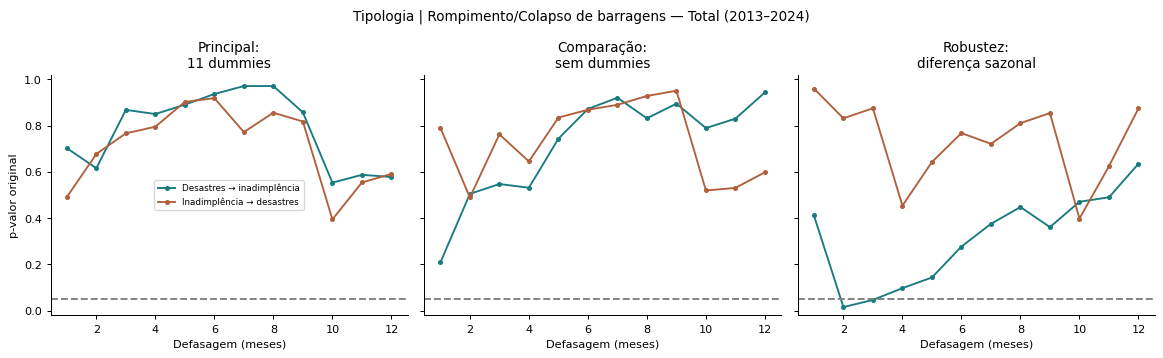

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
216,Principal: 11 dummies,AIC,Desastres → inadimplência,2,0.486966,0.615649,0.847699,1.0,0.659845,0.255887,141,2,125,2
217,Principal: 11 dummies,AIC,Inadimplência → desastres,2,0.391085,0.677147,0.864835,1.0,0.752298,0.582094,141,2,125,2
218,Principal: 11 dummies,BIC,Desastres → inadimplência,2,0.486966,0.615649,0.847699,1.0,0.659845,0.255887,141,2,125,2
219,Principal: 11 dummies,BIC,Inadimplência → desastres,2,0.391085,0.677147,0.864835,1.0,0.752298,0.582094,141,2,125,2
220,Comparação: sem dummies,AIC,Desastres → inadimplência,7,0.366378,0.920179,0.969695,1.0,0.812265,0.235249,136,7,121,7
221,Comparação: sem dummies,AIC,Inadimplência → desastres,7,0.417888,0.889620,0.937492,1.0,0.869920,0.075187,136,7,121,7
222,Comparação: sem dummies,BIC,Desastres → inadimplência,2,0.687416,0.504612,0.837319,1.0,0.267828,0.011079,141,2,136,2
223,Comparação: sem dummies,BIC,Inadimplência → desastres,2,0.719007,0.489078,0.761149,1.0,0.415188,0.125841,141,2,136,2
224,Robustez: diferença sazonal,AIC,Desastres → inadimplência,12,0.814830,0.634640,0.847699,1.0,0.899425,0.032208,119,12,94,12
225,Robustez: diferença sazonal,AIC,Inadimplência → desastres,12,0.552634,0.874118,0.933259,1.0,0.921250,0.465577,119,12,94,12


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
216,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.659583,2.522437e-01,3.100791e-01,-0.033174,False,2.256096e-10,0.151423,Estacionária: convergente,Estacionária: convergente
217,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.659583,2.522437e-01,1.096339e-01,0.002039,False,1.390526e-23,0.058237,Estacionária: convergente,Estacionária: convergente
218,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.659583,2.522437e-01,3.100791e-01,-0.033174,False,2.256096e-10,0.151423,Estacionária: convergente,Estacionária: convergente
219,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.659583,2.522437e-01,1.096339e-01,0.002039,False,1.390526e-23,0.058237,Estacionária: convergente,Estacionária: convergente
220,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.937268,2.873554e-02,8.958044e-03,0.194452,True,2.695506e-24,0.281465,Estacionária: convergente,Estacionária: convergente
221,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.937268,2.873554e-02,1.827674e-03,0.078462,False,3.214712e-85,0.589603,Estacionária: convergente,Estacionária: convergente
222,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.614156,6.312273e-10,1.364329e-16,0.399875,True,7.626640e-07,0.051289,Estacionária: convergente,Estacionária: convergente
223,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.614156,6.312273e-10,1.386473e-01,0.088550,False,3.827560e-48,0.466652,Estacionária: convergente,Estacionária: convergente
224,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.973770,1.348996e-03,1.207144e-04,-0.152325,False,7.525252e-01,0.919690,Estacionária: convergente,Estacionária: convergente
225,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.973770,1.348996e-03,3.427854e-05,-0.196365,True,2.332295e-20,0.931912,Estacionária: convergente,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 2, p=0.6156, BH=0.8477, n=141; BIC: lag 2, p=0.6156, BH=0.8477, n=141.

**Comparação: sem dummies** — AIC: lag 7, p=0.9202, BH=0.9697, n=136; BIC: lag 2, p=0.5046, BH=0.8373, n=141.

**Robustez: diferença sazonal** — AIC: lag 12, p=0.6346, BH=0.8477, n=119; BIC: lag 2, p=0.01529, BH=0.2586, n=129.

Na direção principal, 1/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 0 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 8/12 linhas; 5 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Rompimento/Colapso de barragens — Pré-pandemia (até jan/2020)

,Período,Chave,Nível,Categoria,Motivo
1,Pré-pandemia (até jan/2020),Tipologia | Rompimento/Colapso de barragens,Tipologia,Rompimento/Colapso de barragens,Constante ou rara (<12 meses positivos ou <24 protocolos); in...


### Tipologia | Tornado — Total (2013–2024)

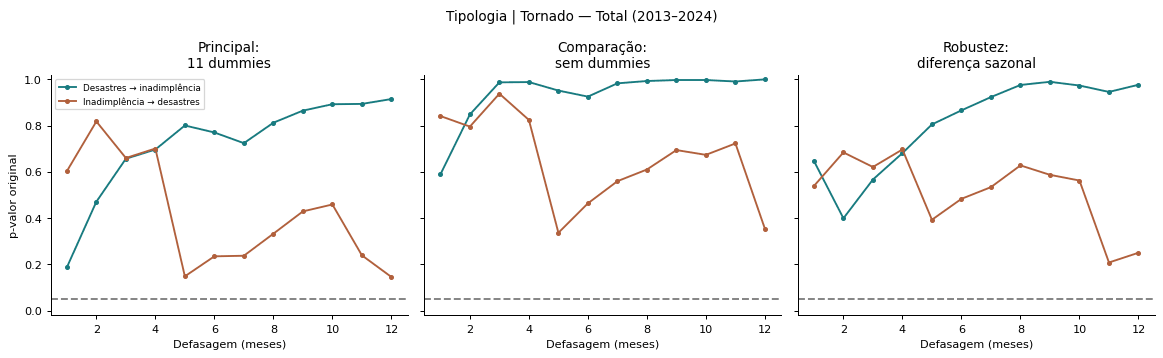

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
228,Principal: 11 dummies,AIC,Desastres → inadimplência,5,0.466822,0.800283,0.918632,1.0,0.882843,0.426782,138,5,116,5
229,Principal: 11 dummies,AIC,Inadimplência → desastres,5,1.666321,0.148217,0.395807,1.0,0.500612,0.275884,138,5,116,5
230,Principal: 11 dummies,BIC,Desastres → inadimplência,1,1.759779,0.187014,0.697592,1.0,0.199688,0.028233,142,1,128,1
231,Principal: 11 dummies,BIC,Inadimplência → desastres,1,0.272442,0.602601,0.806519,1.0,0.677090,0.507823,142,1,128,1
232,Comparação: sem dummies,AIC,Desastres → inadimplência,7,0.210747,0.982434,0.990867,1.0,0.975172,0.928112,136,7,121,7
233,Comparação: sem dummies,AIC,Inadimplência → desastres,7,0.836064,0.559471,0.796142,1.0,0.815229,0.205540,136,7,121,7
234,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.293846,0.588634,0.847699,1.0,0.554646,0.389992,142,1,139,1
235,Comparação: sem dummies,BIC,Inadimplência → desastres,1,0.040331,0.841127,0.927333,1.0,0.849618,0.820384,142,1,139,1
236,Robustez: diferença sazonal,AIC,Desastres → inadimplência,12,0.352163,0.976256,0.990867,1.0,0.994667,0.471597,119,12,94,12
237,Robustez: diferença sazonal,AIC,Inadimplência → desastres,12,1.268775,0.250110,0.515578,1.0,0.249242,0.000002,119,12,94,12


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
228,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.790897,2.471747e-01,3.435818e-01,-0.092392,False,4.106045e-14,0.044773,Estacionária: convergente,Estacionária: convergente
229,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.790897,2.471747e-01,4.624184e-02,-0.045780,False,4.695036e-04,0.047940,Estacionária: convergente,Estacionária: convergente
230,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.530327,2.105322e-03,2.242827e-01,-0.075606,False,4.908667e-05,0.278806,Estacionária: convergente,Estacionária: convergente
231,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.530327,2.105322e-03,3.692072e-04,-0.064916,False,9.168020e-02,0.318663,Estacionária: convergente,Estacionária: convergente
232,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.938917,3.953233e-02,2.232276e-03,0.225324,True,5.411786e-21,0.488464,Estacionária: convergente,Estacionária: convergente
233,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.938917,3.953233e-02,8.341252e-03,0.041854,False,3.761489e-08,0.487440,Estacionária: convergente,Estacionária: convergente
234,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.514886,2.131611e-10,9.132966e-14,0.399390,True,1.661786e-04,0.159531,Estacionária: convergente,Estacionária: convergente
235,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.514886,2.131611e-10,9.836398e-04,0.008958,False,3.515415e-03,0.808662,Estacionária: convergente,Estacionária: convergente
236,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.973577,2.628300e-06,4.670493e-05,-0.201493,True,5.688223e-01,0.910273,Estacionária: convergente,Estacionária: convergente
237,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.973577,2.628300e-06,7.817822e-09,-0.249859,True,5.372748e-01,0.860640,Estacionária: convergente,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 5, p=0.8003, BH=0.9186, n=138; BIC: lag 1, p=0.187, BH=0.6976, n=142.

**Comparação: sem dummies** — AIC: lag 7, p=0.9824, BH=0.9909, n=136; BIC: lag 1, p=0.5886, BH=0.8477, n=142.

**Robustez: diferença sazonal** — AIC: lag 12, p=0.9763, BH=0.9909, n=119; BIC: lag 1, p=0.6469, BH=0.8477, n=130.

Na direção principal, 0/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 0 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 10/12 linhas; 6 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Tornado — Pré-pandemia (até jan/2020)

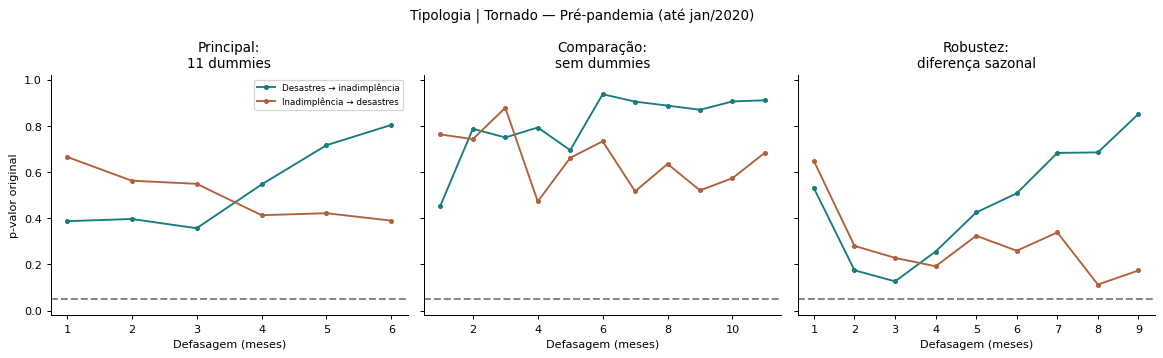

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
456,Principal: 11 dummies,AIC,Desastres → inadimplência,4,0.774035,0.546413,0.837887,1.0,0.506793,0.125577,80,4,60,4
457,Principal: 11 dummies,AIC,Inadimplência → desastres,4,1.002602,0.413378,0.679775,1.0,0.224467,0.000070,80,4,60,4
458,Principal: 11 dummies,BIC,Desastres → inadimplência,3,1.097288,0.356944,0.830090,1.0,0.379421,0.150080,81,3,63,3
459,Principal: 11 dummies,BIC,Inadimplência → desastres,3,0.710506,0.549341,0.796142,1.0,0.614719,0.167197,81,3,63,3
460,Comparação: sem dummies,AIC,Desastres → inadimplência,6,0.294525,0.937427,0.979090,1.0,0.940142,0.064482,78,6,65,6
461,Comparação: sem dummies,AIC,Inadimplência → desastres,6,0.594571,0.733526,0.896667,1.0,0.696435,0.002608,78,6,65,6
462,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.564524,0.454648,0.837319,1.0,0.414761,0.143684,83,1,80,1
463,Comparação: sem dummies,BIC,Inadimplência → desastres,1,0.091376,0.763220,0.897947,1.0,0.787689,0.760346,83,1,80,1
464,Robustez: diferença sazonal,AIC,Desastres → inadimplência,4,1.367775,0.256068,0.802346,1.0,0.279794,0.067237,68,4,59,4
465,Robustez: diferença sazonal,AIC,Inadimplência → desastres,4,1.578020,0.192045,0.435631,1.0,0.118518,0.003718,68,4,59,4


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
456,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.834671,0.115124,1.821434e-01,-0.162280,False,1.600577e-02,0.317083,Inconclusiva: nenhum rejeita,Estacionária: convergente
457,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.834671,0.115124,1.292159e-01,0.027104,False,1.988241e-06,0.649662,Inconclusiva: nenhum rejeita,Estacionária: convergente
458,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.838497,0.075572,4.239195e-01,-0.161329,False,4.899724e-03,0.596163,Inconclusiva: nenhum rejeita,Estacionária: convergente
459,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.838497,0.075572,1.719218e-01,0.019898,False,9.647253e-04,0.445897,Inconclusiva: nenhum rejeita,Estacionária: convergente
460,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.942143,0.007352,1.331888e-02,0.111915,False,2.285001e-01,0.392724,Inconclusiva: nenhum rejeita,Estacionária: convergente
461,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.942143,0.007352,2.829285e-02,0.080350,False,4.451754e-16,0.736752,Inconclusiva: nenhum rejeita,Estacionária: convergente
462,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.546597,0.000001,1.243129e-07,0.352184,True,7.891723e-02,0.493425,Inconclusiva: nenhum rejeita,Estacionária: convergente
463,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.546597,0.000001,1.476297e-02,0.193182,False,4.335591e-04,0.994321,Inconclusiva: nenhum rejeita,Estacionária: convergente
464,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.814288,0.064590,6.890841e-03,-0.375503,True,9.754786e-01,0.718325,Inconclusiva: nenhum rejeita,Estacionária: convergente
465,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.814288,0.064590,1.000810e-02,-0.318429,True,6.833171e-02,0.453145,Inconclusiva: nenhum rejeita,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 4, p=0.5464, BH=0.8379, n=80; BIC: lag 3, p=0.3569, BH=0.8301, n=81.

**Comparação: sem dummies** — AIC: lag 6, p=0.9374, BH=0.9791, n=78; BIC: lag 1, p=0.4546, BH=0.8373, n=83.

**Robustez: diferença sazonal** — AIC: lag 4, p=0.2561, BH=0.8023, n=68; BIC: lag 1, p=0.5305, BH=0.8379, n=71.

Na direção principal, 0/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 0 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 6/12 linhas; 5 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Neste recorte, a estacionariedade da inadimplência transformada não tem confirmação conjunta. Os testes Granger são exploratórios; a ausência de rejeição do ADF não demonstra não estacionariedade, mas a limitação impede uma conclusão robusta.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Vendavais e Ciclones — Total (2013–2024)

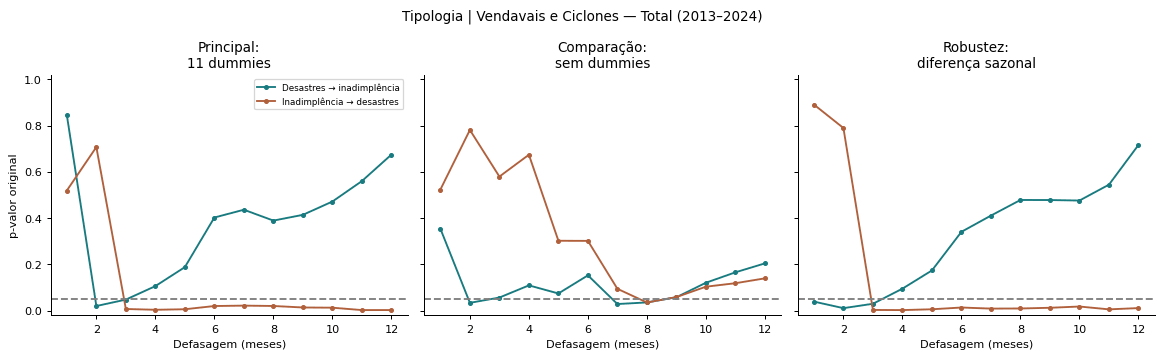

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
240,Principal: 11 dummies,AIC,Desastres → inadimplência,3,2.716419,0.047680,0.397242,1.000000,0.005228,4.857194e-07,140,3,122,3
241,Principal: 11 dummies,AIC,Inadimplência → desastres,3,4.221046,0.007058,0.103669,0.626049,0.056285,7.208905e-02,140,3,122,3
242,Principal: 11 dummies,BIC,Desastres → inadimplência,3,2.716419,0.047680,0.397242,1.000000,0.005228,4.857194e-07,140,3,122,3
243,Principal: 11 dummies,BIC,Inadimplência → desastres,3,4.221046,0.007058,0.103669,0.626049,0.056285,7.208905e-02,140,3,122,3
244,Comparação: sem dummies,AIC,Desastres → inadimplência,9,1.905598,0.057818,0.437989,1.000000,0.073533,6.912003e-06,134,9,115,9
245,Comparação: sem dummies,AIC,Inadimplência → desastres,9,1.900388,0.058592,0.229486,1.000000,0.121761,3.607713e-06,134,9,115,9
246,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.864668,0.354048,0.830090,1.000000,0.408094,1.110120e-01,142,1,139,1
247,Comparação: sem dummies,BIC,Inadimplência → desastres,1,0.409601,0.523226,0.783172,1.000000,0.715342,6.235934e-01,142,1,139,1
248,Robustez: diferença sazonal,AIC,Desastres → inadimplência,12,0.732846,0.716082,0.883025,1.000000,0.674130,1.090386e-03,119,12,94,12
249,Robustez: diferença sazonal,AIC,Inadimplência → desastres,12,2.351126,0.010943,0.116887,0.705874,0.062906,1.793866e-09,119,12,94,12


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
240,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.724018,3.821435e-01,6.191830e-01,-0.063143,False,3.809300e-22,0.018833,Estacionária: convergente,Estacionária: convergente
241,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.724018,3.821435e-01,2.632375e-02,-0.105888,False,4.557853e-10,0.000118,Estacionária: convergente,Estacionária: convergente
242,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.724018,3.821435e-01,6.191830e-01,-0.063143,False,3.809300e-22,0.018833,Estacionária: convergente,Estacionária: convergente
243,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.724018,3.821435e-01,2.632375e-02,-0.105888,False,4.557853e-10,0.000118,Estacionária: convergente,Estacionária: convergente
244,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.951710,8.089600e-03,4.495680e-03,0.161376,False,2.876709e-17,0.089440,Estacionária: convergente,Estacionária: convergente
245,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.951710,8.089600e-03,6.515096e-02,0.013932,False,1.152198e-05,0.000668,Estacionária: convergente,Estacionária: convergente
246,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.361353,2.897192e-12,3.968751e-12,0.383178,True,1.063834e-03,0.148017,Estacionária: convergente,Estacionária: convergente
247,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.361353,2.897192e-12,3.226394e-02,0.150965,False,5.850909e-04,0.000060,Estacionária: convergente,Estacionária: convergente
248,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.969780,1.035374e-04,8.336354e-06,-0.151842,False,1.522951e-01,0.945489,Estacionária: convergente,Estacionária: convergente
249,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.969780,1.035374e-04,1.465677e-08,-0.326002,True,8.687384e-03,0.568491,Estacionária: convergente,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 3, p=0.04768, BH=0.3972, n=140; BIC: lag 3, p=0.04768, BH=0.3972, n=140.

**Comparação: sem dummies** — AIC: lag 9, p=0.05782, BH=0.438, n=134; BIC: lag 1, p=0.354, BH=0.8301, n=142.

**Robustez: diferença sazonal** — AIC: lag 12, p=0.7161, BH=0.883, n=119; BIC: lag 3, p=0.02961, BH=0.3311, n=128.

Na direção principal, 3/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 4 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 8/12 linhas; 4 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Tipologia | Vendavais e Ciclones — Pré-pandemia (até jan/2020)

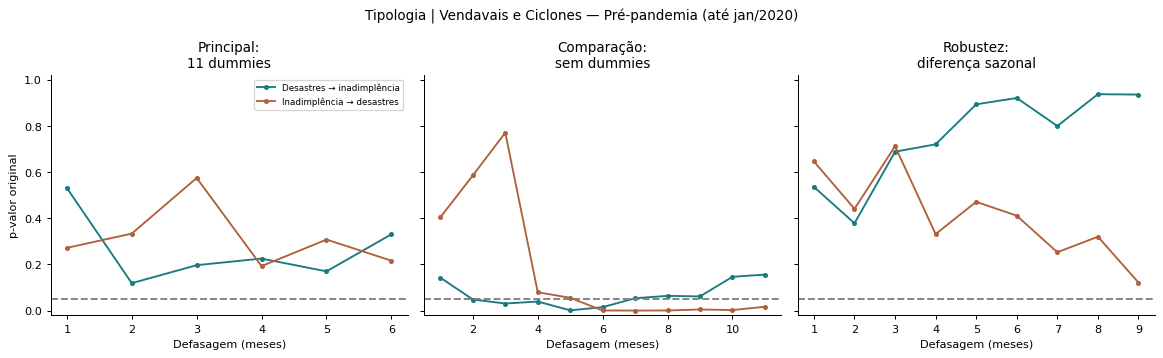

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
468,Principal: 11 dummies,AIC,Desastres → inadimplência,4,1.460649,0.225453,0.756878,1.000000,0.237913,2.383882e-06,80,4,60,4
469,Principal: 11 dummies,AIC,Inadimplência → desastres,4,1.574310,0.192790,0.435631,1.000000,0.467399,1.863739e-02,80,4,60,4
470,Principal: 11 dummies,BIC,Desastres → inadimplência,1,0.395768,0.531360,0.837887,1.000000,0.542600,2.819402e-01,83,1,69,1
471,Principal: 11 dummies,BIC,Inadimplência → desastres,1,1.226523,0.271930,0.541957,1.000000,0.425396,2.952754e-01,83,1,69,1
472,Comparação: sem dummies,AIC,Desastres → inadimplência,11,1.513672,0.156292,0.655870,1.000000,0.087442,5.014211e-10,73,11,50,11
473,Comparação: sem dummies,AIC,Inadimplência → desastres,11,2.422639,0.016688,0.127638,0.770798,0.089833,1.327322e-08,73,11,50,11
474,Comparação: sem dummies,BIC,Desastres → inadimplência,1,2.189506,0.142881,0.655870,1.000000,0.104819,1.425372e-03,83,1,80,1
475,Comparação: sem dummies,BIC,Inadimplência → desastres,1,0.702518,0.404436,0.679775,1.000000,0.502655,4.201209e-01,83,1,80,1
476,Robustez: diferença sazonal,AIC,Desastres → inadimplência,4,0.521212,0.720460,0.883025,1.000000,0.626364,2.153115e-01,68,4,59,4
477,Robustez: diferença sazonal,AIC,Inadimplência → desastres,4,1.174074,0.331522,0.618316,1.000000,0.417517,8.350670e-02,68,4,59,4


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
468,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.816402,2.159874e-02,0.057236,-0.227316,True,0.045636,0.551168,Inconclusiva: nenhum rejeita,Estacionária: convergente
469,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.816402,2.159874e-02,0.024289,-0.046519,False,0.746046,0.334994,Inconclusiva: nenhum rejeita,Estacionária: convergente
470,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.614322,2.382627e-02,0.004525,-0.093453,False,0.754924,0.942947,Inconclusiva: nenhum rejeita,Estacionária: convergente
471,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.614322,2.382627e-02,0.212072,0.014452,False,0.562307,0.195320,Inconclusiva: nenhum rejeita,Estacionária: convergente
472,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.983085,5.061984e-03,0.052941,-0.156164,False,0.000249,0.484225,Inconclusiva: nenhum rejeita,Estacionária: convergente
473,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.983085,5.061984e-03,0.002857,-0.045486,False,0.361659,0.232640,Inconclusiva: nenhum rejeita,Estacionária: convergente
474,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.432891,2.330822e-09,0.000003,0.337984,True,0.138779,0.780698,Inconclusiva: nenhum rejeita,Estacionária: convergente
475,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.432891,2.330822e-09,0.000635,0.447048,True,0.382575,0.819919,Inconclusiva: nenhum rejeita,Estacionária: convergente
476,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.755875,8.435748e-03,0.000998,-0.425540,True,0.879335,0.986918,Inconclusiva: nenhum rejeita,Estacionária: convergente
477,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.755875,8.435748e-03,0.001897,-0.263226,True,0.603959,0.721821,Inconclusiva: nenhum rejeita,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 4, p=0.2255, BH=0.7569, n=80; BIC: lag 1, p=0.5314, BH=0.8379, n=83.

**Comparação: sem dummies** — AIC: lag 11, p=0.1563, BH=0.6559, n=73; BIC: lag 1, p=0.1429, BH=0.6559, n=83.

**Robustez: diferença sazonal** — AIC: lag 4, p=0.7205, BH=0.883, n=68; BIC: lag 1, p=0.536, BH=0.8379, n=71.

Na direção principal, 0/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 1 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 12/12 linhas; 7 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Neste recorte, a estacionariedade da inadimplência transformada não tem confirmação conjunta. Os testes Granger são exploratórios; a ausência de rejeição do ADF não demonstra não estacionariedade, mas a limitação impede uma conclusão robusta.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

In [5]:
for key in meta[meta.Nível.isin(['Tipologia'])].Chave:
    for periodo in PERIODOS:
        display(Markdown('### '+key+' — '+periodo))
        r=resultados[(resultados.Chave==key)&(resultados.Período==periodo)]
        if r.empty:
            tabela(inviaveis[(inviaveis.Chave==key)&(inviaveis.Período==periodo)])
            continue
        figura_granger(resultados,sensibilidade,key,periodo)
        tabela(r[['Especificação','Critério','Direção','Defasagem','F','p','p BH','p BY','p HC3','p HAC12','n efetivo','GL numerador','GL denominador','Ótimo incluindo zero']])
        tabela(r[['Especificação','Critério','Direção','Estável','Raiz máxima','Portmanteau p','Ljung–Box p','ACF(12)','Pico sazonal','Jarque–Bera p','Breusch–Pagan p','Estacionariedade I','Estacionariedade D']])
        interpretar_granger(resultados,key,periodo)


## Consistência e conclusão

Os indicadores abaixo exigem significância BH para falar em consistência. Mesmo quando há concordância entre períodos, as amostras se sobrepõem. Diagnósticos favoráveis em um único cenário não bastam para um achado geral.

In [6]:
tabela(comparacao[comparacao.Nível.isin(['Tipologia'])])

,Chave,Nível,Categoria,Direção,Linhas nominais,Linhas BH,Linhas BY,AIC e BIC significativos no mesmo cenário,Três especificações significativas no mesmo período/critério,Dois períodos significativos na mesma especificação/critério,Linhas BH com diagnósticos favoráveis
8,Tipologia | Alagamentos,Tipologia,Alagamentos,Desastres → inadimplência,5,0,0,False,False,False,0
9,Tipologia | Alagamentos,Tipologia,Alagamentos,Inadimplência → desastres,0,0,0,False,False,False,0
10,Tipologia | Chuvas Intensas,Tipologia,Chuvas Intensas,Desastres → inadimplência,2,0,0,False,False,False,0
11,Tipologia | Chuvas Intensas,Tipologia,Chuvas Intensas,Inadimplência → desastres,1,0,0,False,False,False,0
12,Tipologia | Doenças infecciosas,Tipologia,Doenças infecciosas,Desastres → inadimplência,0,0,0,False,False,False,0
13,Tipologia | Doenças infecciosas,Tipologia,Doenças infecciosas,Inadimplência → desastres,2,0,0,False,False,False,0
14,Tipologia | Enxurradas,Tipologia,Enxurradas,Desastres → inadimplência,1,0,0,False,False,False,0
15,Tipologia | Enxurradas,Tipologia,Enxurradas,Inadimplência → desastres,3,0,0,False,False,False,0
16,Tipologia | Erosão,Tipologia,Erosão,Desastres → inadimplência,0,0,0,False,False,False,0
17,Tipologia | Erosão,Tipologia,Erosão,Inadimplência → desastres,2,0,0,False,False,False,0


In [7]:
p=resultados[resultados.Direção=='Desastres → inadimplência']
u=p.drop_duplicates(['Período','Chave','Especificação','Direção','Defasagem'])
display(Markdown(f'Na família principal há **{len(u)} hipóteses únicas**, **{int((u.p<.05).sum())} rejeições nominais** e **{int((u["p BH"]<.05).sum())} após BH**. A ampliação não sustenta uma conclusão robusta de precedência dos desastres sobre a inadimplência nas especificações avaliadas. Isso não prova ausência de efeitos locais ou de outros mecanismos.'))


Na família principal há **235 hipóteses únicas**, **29 rejeições nominais** e **0 após BH**. A ampliação não sustenta uma conclusão robusta de precedência dos desastres sobre a inadimplência nas especificações avaliadas. Isso não prova ausência de efeitos locais ou de outros mecanismos.